In [1]:
# General Imports
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Scripts 
folder_path = os.path.abspath("scripts")
sys.path.append(folder_path)

# Derivation of Column Density Maps Routine
from Derive_Density_Maps import derive_density_maps, convert_to_mass

# Visualization Tools
from visualization_tools import show_regions_with_sections, show_Minkowski_Functionals, show_sections_OrionB_vertical, visualize_Mass_Size_D_Diagrams, visualize_Mass_Size_D_Diagramm_as_One

# Minkowski Functionals
from Minkowski_Fractal_Dimension import standard_minkowski_functionals, horizontal_marching_minkowski_functionals, vertical_marching_minkowski_functionals, intercept_corrected_minkowski_functionals 

# Box Counting 
from Box_Counting_Fractal_Dimension import box_counting

# Dendogram-like Tracker
from region_tracker import track_largest_regions, save_regions_to_pickle, load_regions_from_pickle, get_region_from_fractal_dimension_mass_and_size

# Derive Density Maps
N_H2, N_H2_OA, N_H2_OB, wcs = derive_density_maps()

[14:59:45] ERROR    PARDISO solver not installed, run `pip install pypardiso`. Otherwise,          ]8;id=186178;file://c:\Users\User\anaconda3\envs\Astronomy_Env\Lib\site-packages\openpnm\utils\_workspace.py\_workspace.py]8;;\:]8;id=334636;file://c:\Users\User\anaconda3\envs\Astronomy_Env\Lib\site-packages\openpnm\utils\_workspace.py#56\56]8;;\
                    simulations will be slow. Apple M chips not supported.                                         

# **Mass-Size relation to the fractal dimension**
This Notebook explores the connection of the mass and size scaling properties with the fractal dimension. To this end, the following steps are carried out:

1. Calculate the fractal dimension of the biggest structures at each column density thresholds
2. Assess the trend compared with the general trend (when not divided into substructures)
3. Calculate mass and size of the single sub-structures
4. Assess M-L-D scaling properties 

### **Outlook**
1. Low Band Mass is too high! -> check total mass (seems fine for now. Orion B is really good, Orion A a bit off). Yet still not enough small cores...
2. Very few cores found, why? I think the issue is in this code, specifically in how the structures are found (mask)!
3. Trend doesn't make sense...
4. Save the regions in pickle again cause it takes too long

In [2]:
# Orion A

# overall, these work best for the whole region
threshold_min = 2.5e21
threshold_max = 8.5e22 # This works well when the fractal dimension is calculated for the whole region, but for the individual regions it might be good to go further down

# Minkowski
results_OA = standard_minkowski_functionals(N_H2_OA, threshold_min = threshold_min, threshold_max = threshold_max)

# Orion B

# Minkowski
results_OB = standard_minkowski_functionals(N_H2_OB, threshold_min = threshold_min, threshold_max = threshold_max)

2.868994809242656
2.8085460183953956


## **Method 1 (No MSD, Yes Local Fractal Dimension)**

In [5]:
import scipy.ndimage as ndimage
from skimage.measure import perimeter
import numpy as np

import pickle 

def pca_major_axis(region_coords):
    """
    Computes the major axis length of a structure using PCA.
    The major axis is the square root of the largest eigenvalue of the covariance matrix.
    """
    if len(region_coords) < 2:
        return 0  # If only one pixel, size is zero

    # Center the coordinates
    centered_coords = region_coords - np.mean(region_coords, axis=0)

    # Compute covariance matrix and its eigenvalues
    cov_matrix = np.cov(centered_coords, rowvar=False)
    eigenvalues, _ = np.linalg.eigh(cov_matrix)

    # The largest eigenvalue corresponds to the major axis squared
    major_axis = 2 * np.sqrt(np.max(eigenvalues))  # Factor 2 to approximate full length

    return major_axis

def calculate_mass_and_size(region_mask, M_H2, pc_per_px):
    """
    Calculate the mass and the major axis of a structure using PCA.
    - Mass: Summed pixel values converted to solar masses.
    - Size: Major axis computed from PCA eigenvalues.
    """
    # Compute total mass
    mass = np.sum(M_H2[region_mask]) # * cm2_per_px 

    # Find structure coordinates
    region_coords = np.column_stack(np.where(region_mask))

    if len(region_coords) == 0:
        return mass, 0  # If no region is found, return zero size

    # Compute the major axis length using PCA
    major_axis_length = pca_major_axis(region_coords)

    # Convert size to parsecs
    size_parsecs = major_axis_length * pc_per_px

    return mass, size_parsecs

def compute_fractal_dimension(region_mask):
    """
    Compute the fractal dimension of a binary region using the Perimeter-Area relation.
    
    Parameters:
        region_mask (ndarray): Boolean mask of the structure.
        
    Returns:
        float: Estimated fractal dimension.
    """
    area = np.sum(region_mask)
    
    # Compute perimeter using dilation technique
    mask_perimeter = perimeter(region_mask)

    if area > 0 and mask_perimeter > 0:
        return 2*(np.log10(mask_perimeter) / np.log10(area))
    return None  # Invalid case (avoid division errors)

def track_largest_regions_NEW(N_H2, M_H2, thresholds, pc_per_px, num_top_regions=None, min_region_size_px=50):
    """
    Extract regions at each threshold and compute their properties.
    """
    regions = {}

    for threshold in thresholds:
        mask = N_H2 >= threshold  
        labeled_regions, num_features = ndimage.label(mask)

        if num_features == 0:
            print(f"[{threshold}] No regions found.")
            continue

        region_sizes = {
            region_id: np.sum(labeled_regions == region_id)
            for region_id in range(1, num_features + 1)
        }

        # Filter by size or pick top N
        region_ids = sorted(region_sizes, key=region_sizes.get, reverse=True)
        if num_top_regions is not None:
            region_ids = region_ids[:num_top_regions]

        saved_count = 0
        for region_id in region_ids:
            size_px = region_sizes[region_id]
            if size_px < min_region_size_px:
                continue

            region_mask = labeled_regions == region_id
            fractal_dim = compute_fractal_dimension(region_mask)
            mass, size = calculate_mass_and_size(region_mask, M_H2, pc_per_px)

            region_key = f"{threshold}_{region_id}"
            regions[region_key] = {
                "threshold": threshold,
                "fractal_dimension": fractal_dim,
                "mass": mass,
                "size": size,
                "region_mask": region_mask
            }
            saved_count += 1

        print(f"[{threshold}] Found {num_features} regions, saved {saved_count}.")

    return regions

In [6]:
# Dendograms-like approach to retrieve regions
pixel_scale = 0.00417
distance = 412 
radians = 180/np.pi # conversion factor: rad in deg
rad_per_px = pixel_scale/radians
pc_per_px = np.sin(rad_per_px)*distance

M_H2_OA = convert_to_mass(N_H2_OA)

thresholds = np.logspace(np.log10(threshold_min), np.log10(threshold_max), 100) 

if os.path.exists("top_regions_data_OA.pkl"):
    top_regions_data_OA = load_regions_from_pickle("top_regions_data_OA.pkl")
else:
    top_regions_data_OA = track_largest_regions_NEW(N_H2_OA, M_H2_OA, thresholds, pc_per_px, num_top_regions=15, min_region_size_px=10)
    # save_regions_to_pickle(top_regions_data_OA, "top_regions_data_OA.pkl")

# Plot fractal dimensions for each threshold
thresholds = np.unique([region_data["threshold"] for region_data in top_regions_data_OA.values()])

[2.4999999999999995e+21] Found 801 regions, saved 15.
[2.5906544706295043e+21] Found 764 regions, saved 15.
[2.6845962344770563e+21] Found 635 regions, saved 15.
[2.781944494673271e+21] Found 630 regions, saved 15.
[2.88282277686738e+21] Found 525 regions, saved 15.
[2.987359085969617e+21] Found 528 regions, saved 15.
[3.095686068577144e+21] Found 472 regions, saved 15.
[3.2079411812899425e+21] Found 448 regions, saved 15.
[3.3242668651301144e+21] Found 457 regions, saved 15.
[3.4448107262859726e+21] Found 407 regions, saved 15.
[3.569725723410091e+21] Found 375 regions, saved 15.
[3.6991703617093994e+21] Found 392 regions, saved 15.
[3.833308894073048e+21] Found 404 regions, saved 15.
[3.972311529493674e+21] Found 358 regions, saved 15.
[4.1163546490463993e+21] Found 333 regions, saved 15.
[4.2656210296994414e+21] Found 324 regions, saved 15.
[4.4203000762408365e+21] Found 275 regions, saved 15.
[4.5805880616149063e+21] Found 274 regions, saved 15.
[4.746688375973919e+21] Found 285 re

<>:27: SyntaxWarning: invalid escape sequence '\m'
<>:27: SyntaxWarning: invalid escape sequence '\m'
C:\Users\User\AppData\Local\Temp\ipykernel_6260\4015027180.py:27: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel("Threshold [$\mathrm{cm}^{-2}$]", fontsize=18)


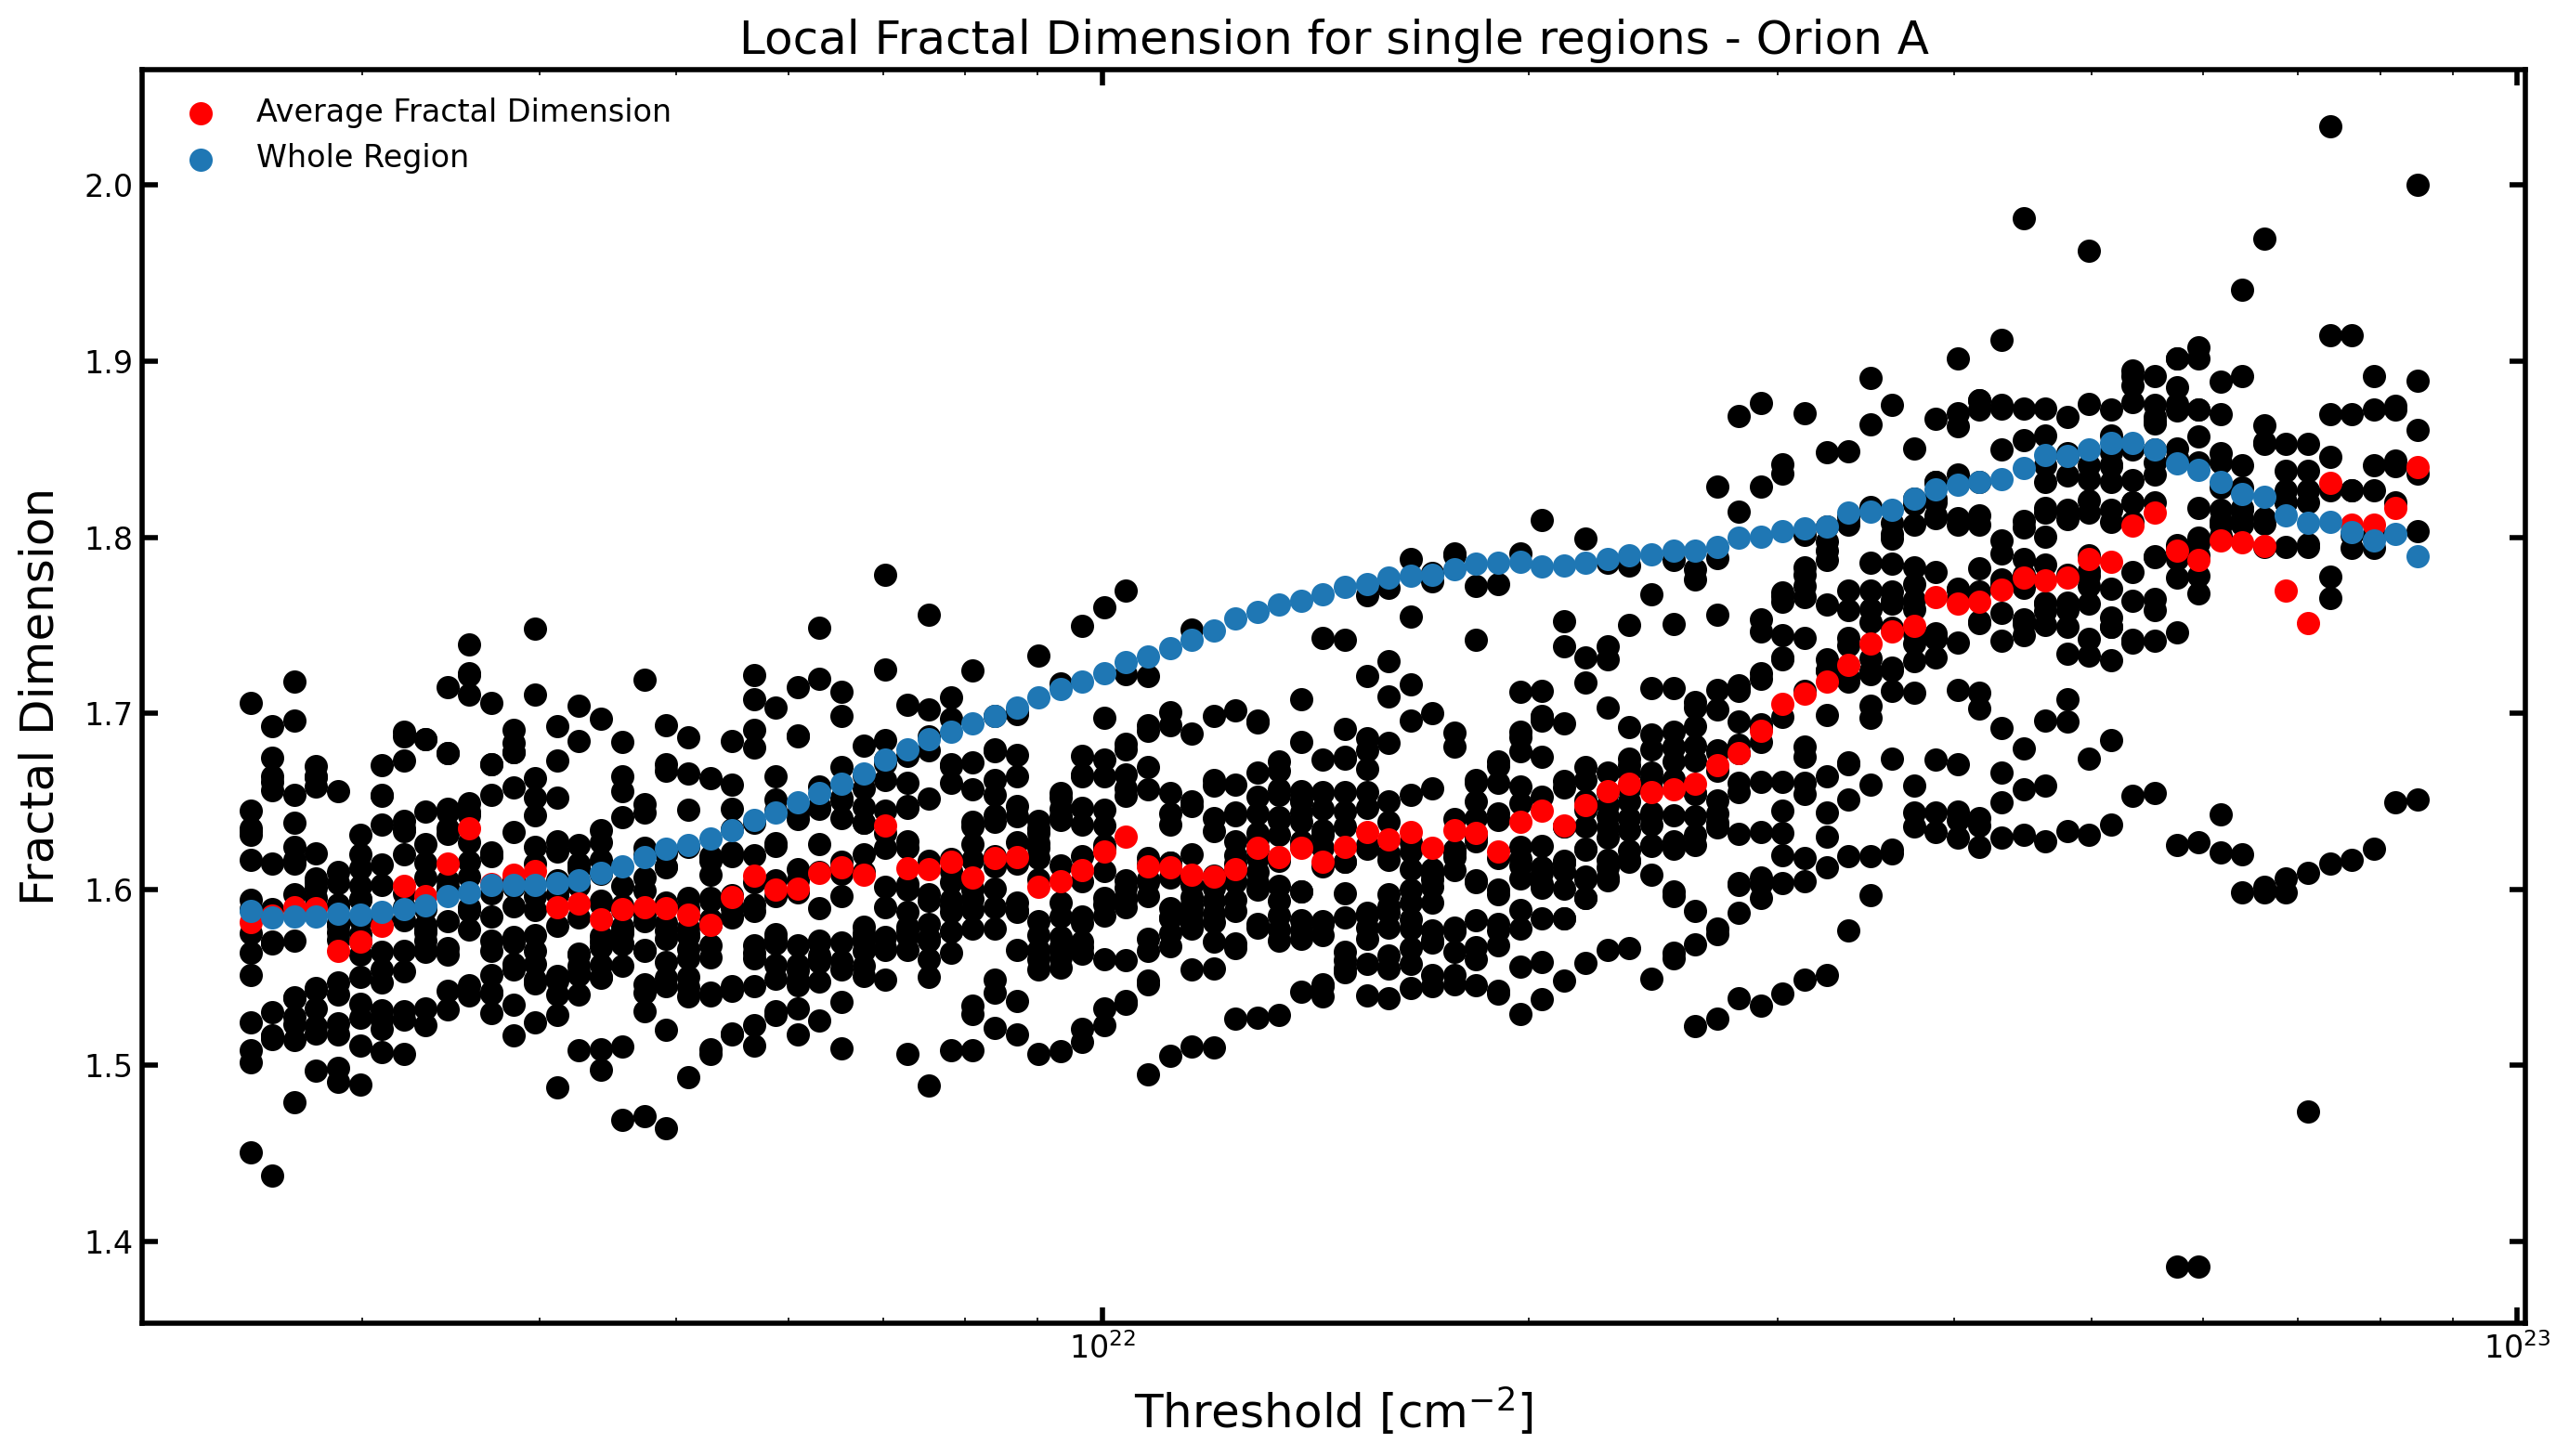

In [10]:
plt.figure(figsize=(14, 8))

average_fractal_dimensions = []

for i, threshold in enumerate(thresholds):
    fractal_dimensions = [
        region_data["fractal_dimension"]
        for region_data in top_regions_data_OA.values()
        if region_data["threshold"] == threshold
    ]
    plt.scatter(
        [threshold] * len(fractal_dimensions),
        fractal_dimensions,
        color="black"
    )
    if fractal_dimensions:
        average_fractal_dimensions.append(np.mean(fractal_dimensions))
    else:
        average_fractal_dimensions.append(np.nan)

plt.scatter(thresholds, average_fractal_dimensions, color='red', label="Average Fractal Dimension")

thresholds_full = np.logspace(np.log10(2.5e21), np.log10(8.5e22), 100)
plt.scatter(thresholds_full, results_OA["fractal_dimension"], label="Whole Region")

plt.xscale("log")
plt.xlabel("Threshold [$\mathrm{cm}^{-2}$]", fontsize=18)
plt.ylabel("Fractal Dimension", fontsize=18)
plt.title("Local Fractal Dimension for single regions - Orion A", fontsize=18)
plt.legend()
plt.show()

In [8]:
# Dendograms-like approach to retrieve regions

pixel_scale = 0.00417
distance = 412 
radians = 180/np.pi #conversion factor: rad in deg
rad_per_px = pixel_scale/radians
pc_per_px = np.sin(rad_per_px)*distance

M_H2_OB = convert_to_mass(N_H2_OB)

thresholds = np.logspace(np.log10(threshold_min), np.log10(threshold_max), 100) 

if os.path.exists("top_regions_data_OB.pkl"):
    top_regions_data_OB = load_regions_from_pickle("top_regions_data_OB.pkl")
else:
    top_regions_data_OB = track_largest_regions_NEW(N_H2_OB, M_H2_OB, thresholds, pc_per_px, num_top_regions=15, min_region_size_px=10)
    # save_regions_to_pickle(top_regions_data_OA, "top_regions_data_OA.pkl")

# Plot fractal dimensions for each threshold
thresholds = np.unique([region_data["threshold"] for region_data in top_regions_data_OB.values()])

[2.4999999999999995e+21] Found 788 regions, saved 15.
[2.5906544706295043e+21] Found 692 regions, saved 15.
[2.6845962344770563e+21] Found 695 regions, saved 15.
[2.781944494673271e+21] Found 662 regions, saved 15.
[2.88282277686738e+21] Found 592 regions, saved 15.
[2.987359085969617e+21] Found 514 regions, saved 15.
[3.095686068577144e+21] Found 532 regions, saved 15.
[3.2079411812899425e+21] Found 537 regions, saved 15.
[3.3242668651301144e+21] Found 508 regions, saved 15.
[3.4448107262859726e+21] Found 485 regions, saved 15.
[3.569725723410091e+21] Found 422 regions, saved 15.
[3.6991703617093994e+21] Found 420 regions, saved 15.
[3.833308894073048e+21] Found 393 regions, saved 15.
[3.972311529493674e+21] Found 352 regions, saved 15.
[4.1163546490463993e+21] Found 326 regions, saved 15.
[4.2656210296994414e+21] Found 284 regions, saved 15.
[4.4203000762408365e+21] Found 256 regions, saved 15.
[4.5805880616149063e+21] Found 258 regions, saved 15.
[4.746688375973919e+21] Found 232 re

<>:28: SyntaxWarning: invalid escape sequence '\m'
<>:28: SyntaxWarning: invalid escape sequence '\m'
C:\Users\User\AppData\Local\Temp\ipykernel_6260\2010585322.py:28: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel("Threshold [$\mathrm{cm}^{-2}$]", fontsize=18)


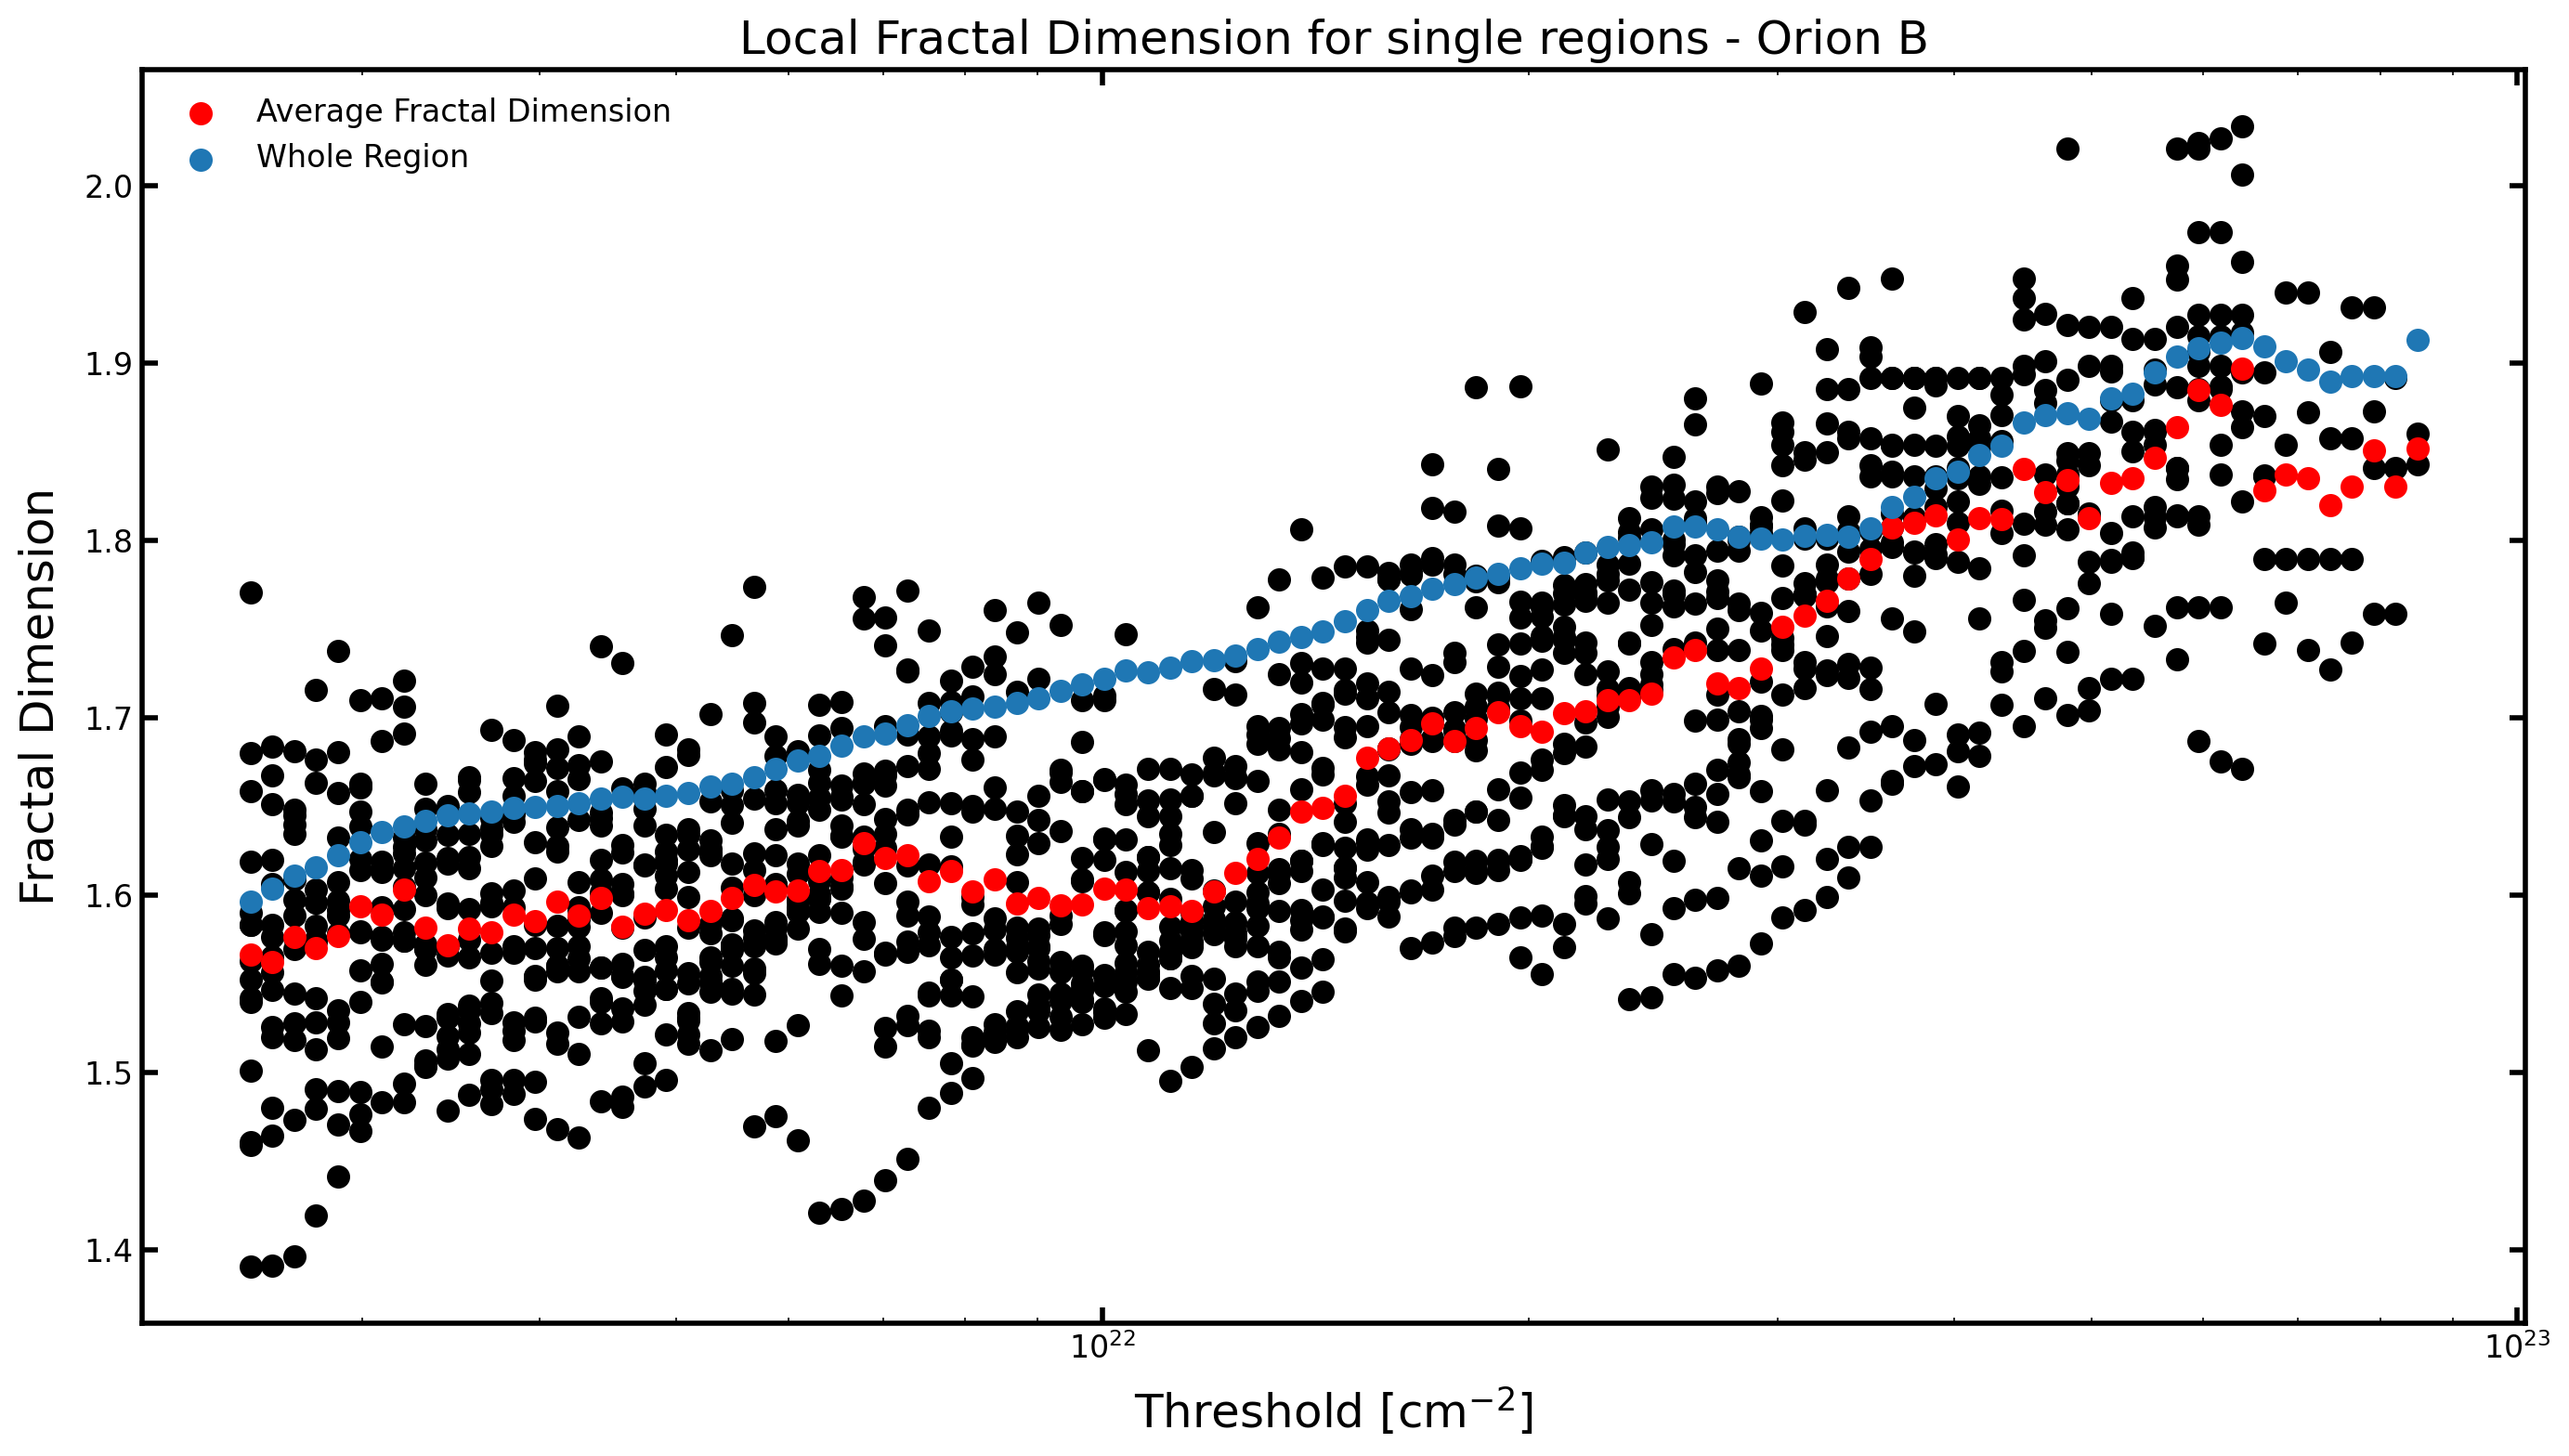

In [11]:
plt.figure(figsize=(14, 8))

average_fractal_dimensions = []

for i, threshold in enumerate(thresholds):
    fractal_dimensions = [
        region_data["fractal_dimension"]
        for region_data in top_regions_data_OB.values()
        if region_data["threshold"] == threshold
    ]
    plt.scatter(
        [threshold] * len(fractal_dimensions),
        fractal_dimensions,
        color="black"
    )
    if fractal_dimensions:
        average_fractal_dimensions.append(np.mean(fractal_dimensions))
    else:
        average_fractal_dimensions.append(np.nan)

plt.scatter(thresholds, average_fractal_dimensions, color='red', label="Average Fractal Dimension")

thresholds_full = np.logspace(np.log10(2.5e21), np.log10(8.5e22), 100)

plt.scatter(thresholds_full, results_OB["fractal_dimension"], label="Whole Region")

plt.xscale("log")
plt.xlabel("Threshold [$\mathrm{cm}^{-2}$]", fontsize=18)
plt.ylabel("Fractal Dimension", fontsize=18)
plt.title("Local Fractal Dimension for single regions - Orion B", fontsize=18)
plt.legend()
plt.show()

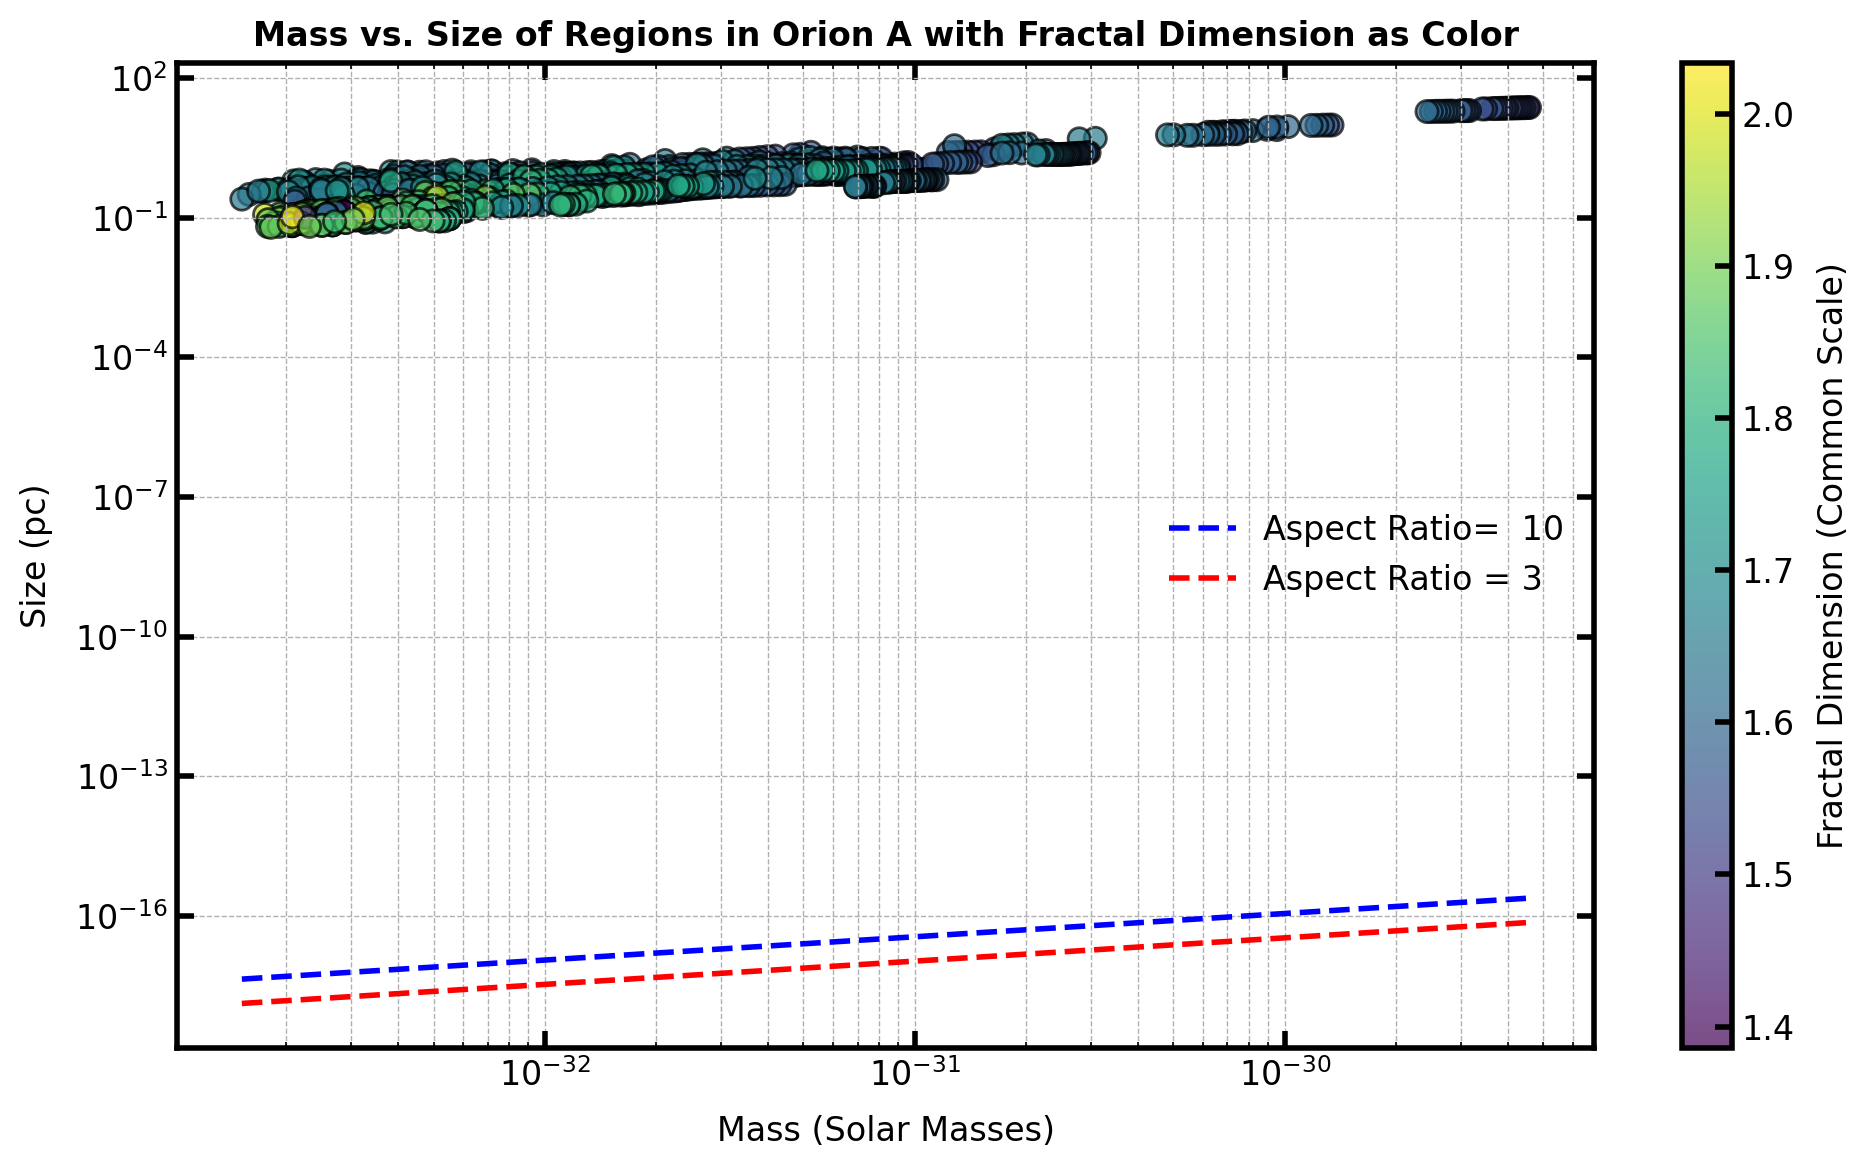

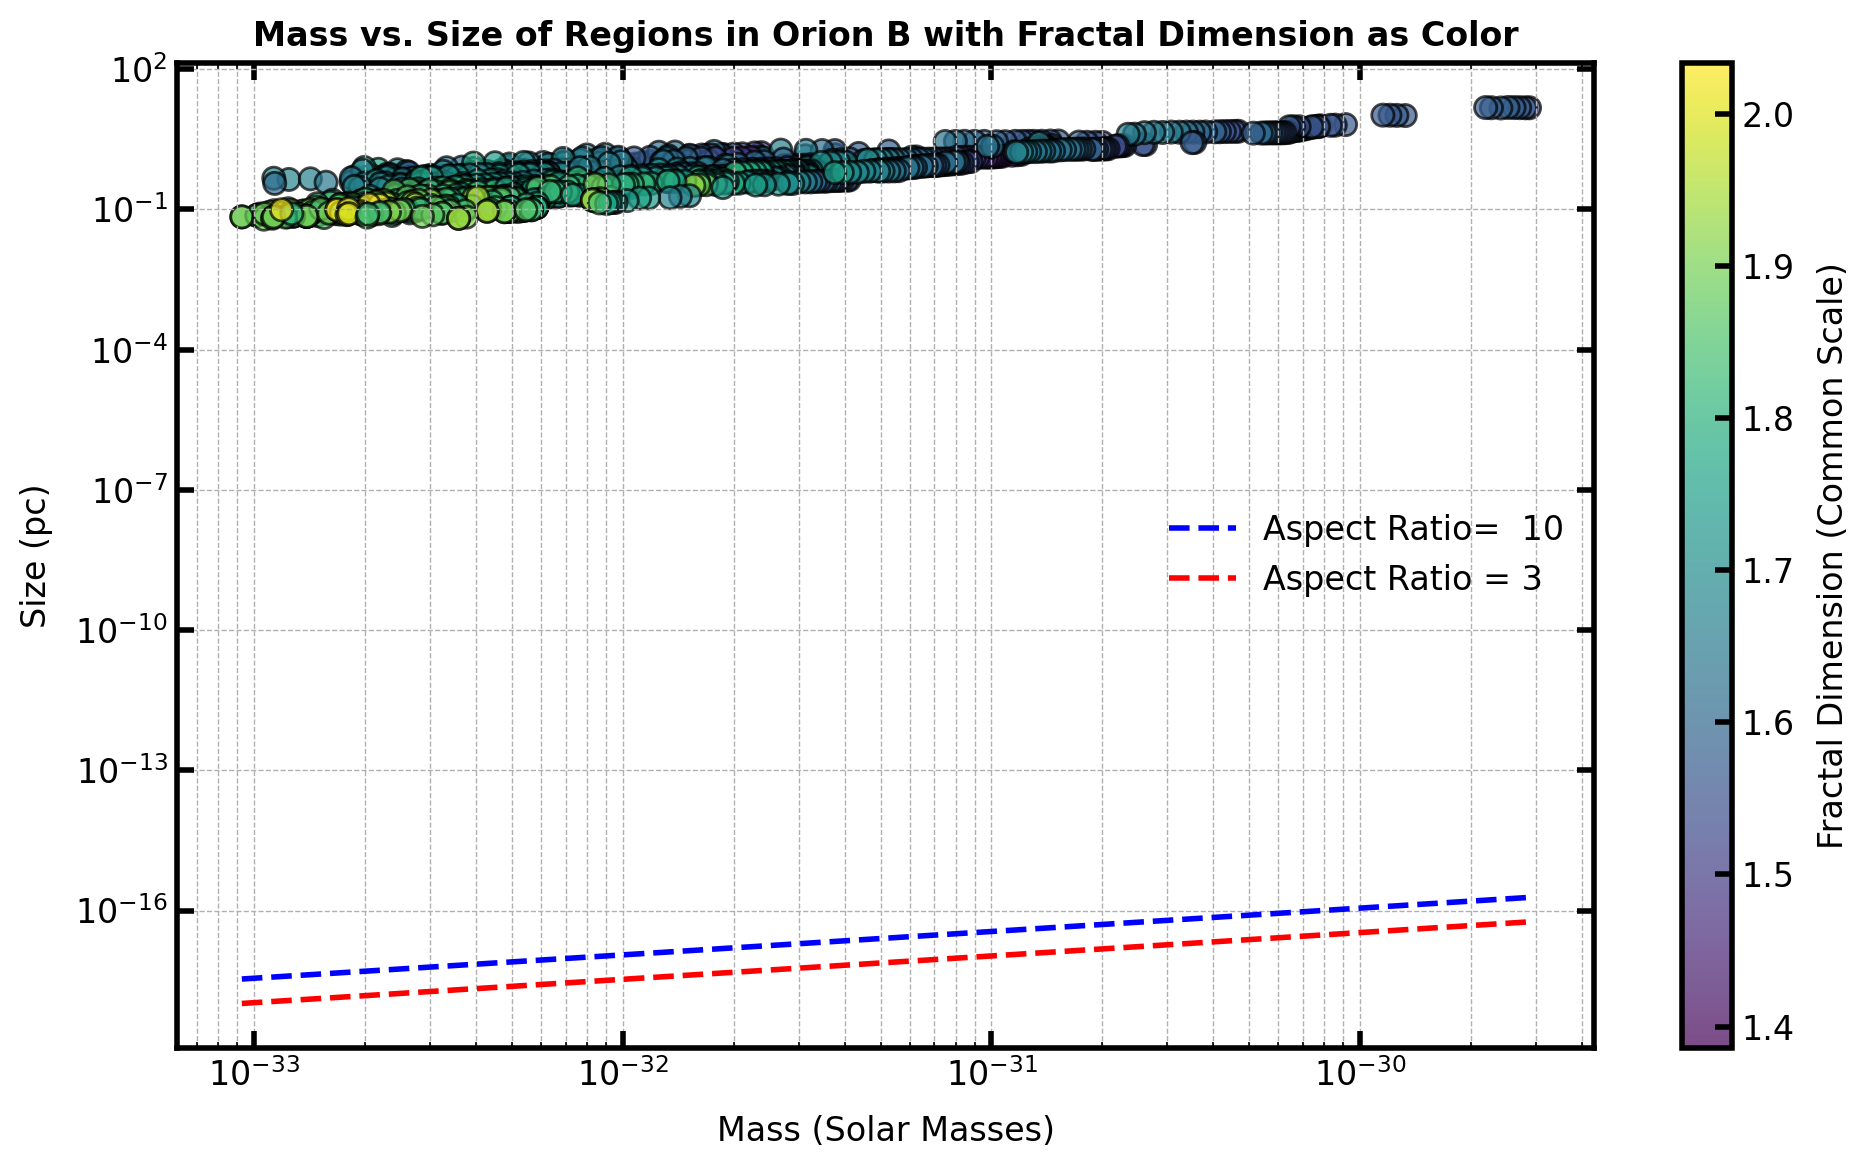

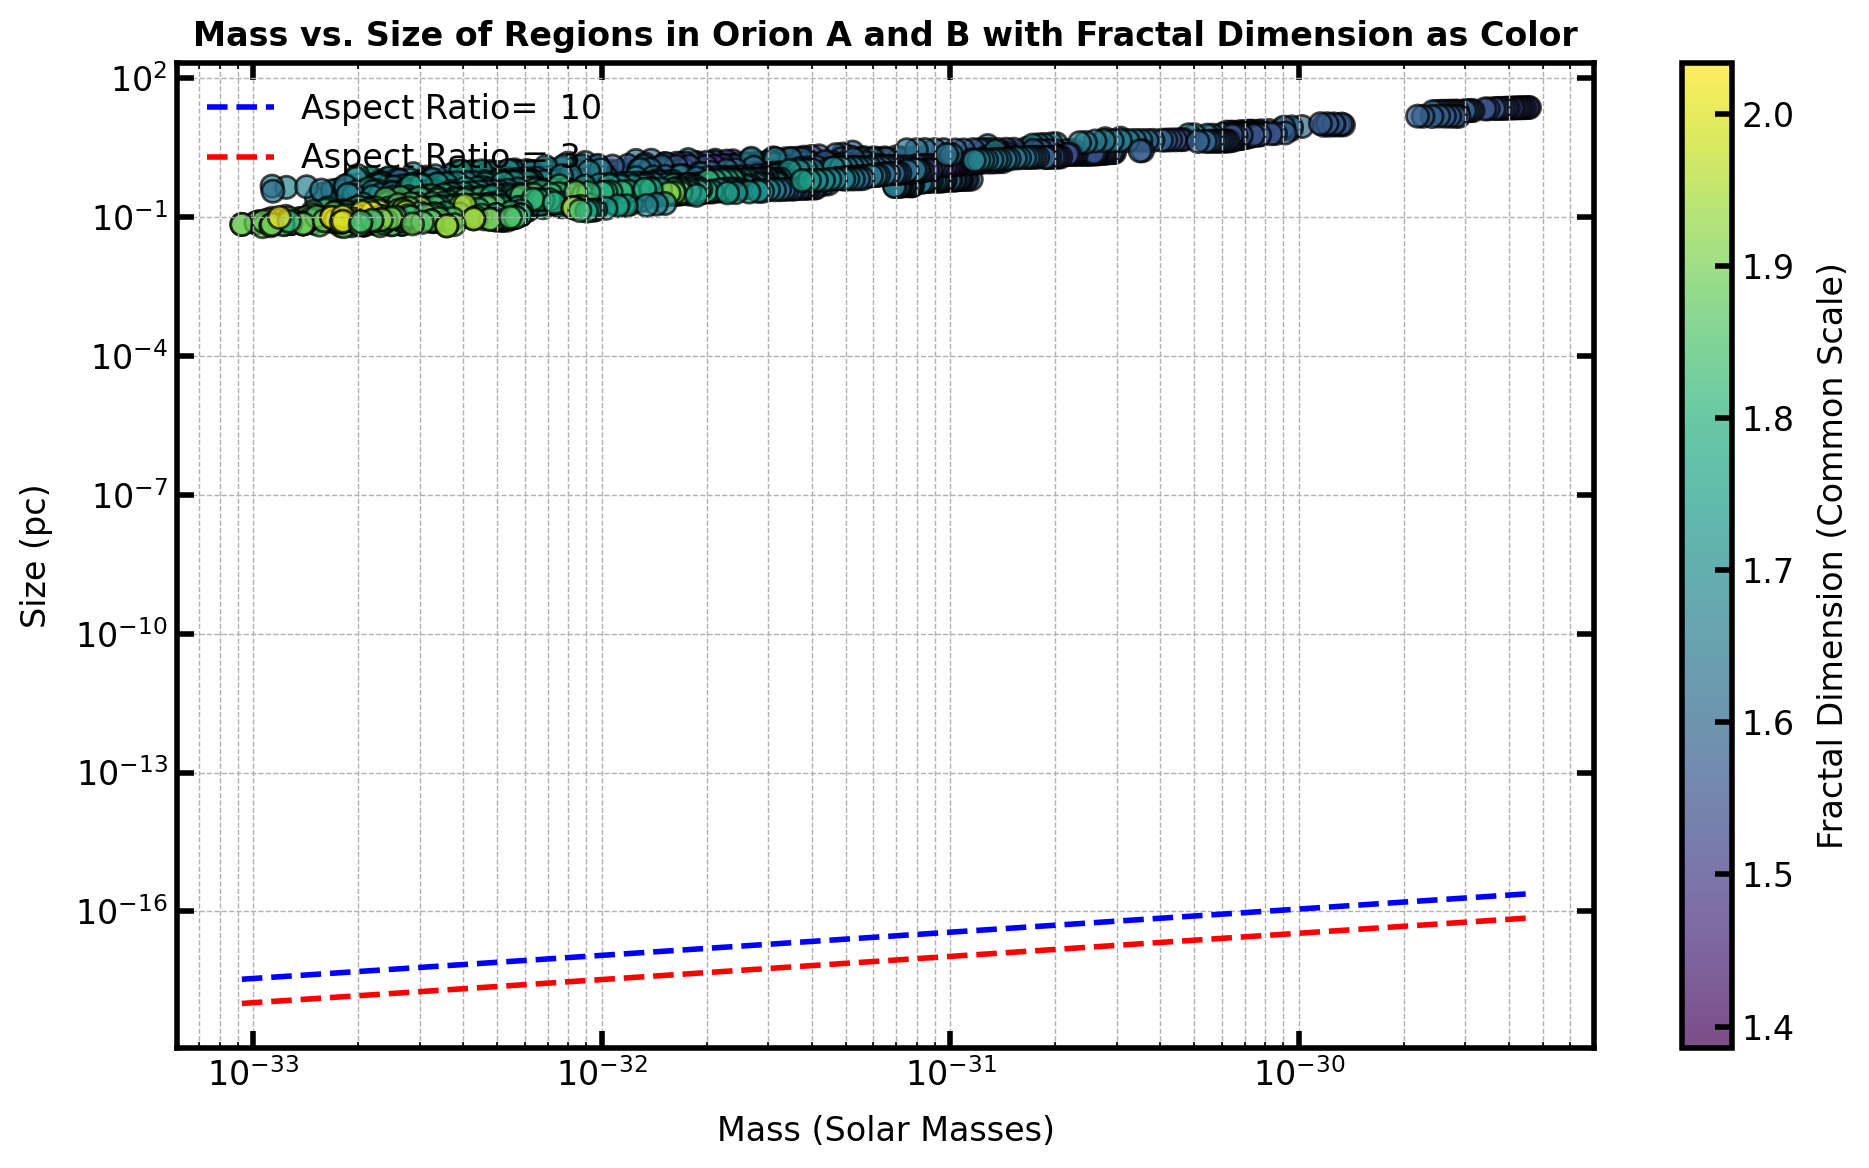

In [ ]:
# Extract fractal dimensions, sizes, and masses for Orion A and B
fractal_dims_OA = [region_data["fractal_dimension"] for region_data in top_regions_data_OA.values()]
sizes_OA = [region_data["size"] for region_data in top_regions_data_OA.values()]
masses_OA = [region_data["mass"] for region_data in top_regions_data_OA.values()]

fractal_dims_OB = [region_data["fractal_dimension"] for region_data in top_regions_data_OB.values()]
sizes_OB = [region_data["size"] for region_data in top_regions_data_OB.values()]
masses_OB = [region_data["mass"] for region_data in top_regions_data_OB.values()]

# Single Regions
visualize_Mass_Size_D_Diagrams(fractal_dims_OA, fractal_dims_OB, masses_OA, masses_OB, sizes_OA, sizes_OB)

# All
visualize_Mass_Size_D_Diagramm_as_One(fractal_dims_OA, fractal_dims_OB, masses_OA, masses_OB, sizes_OA, sizes_OB)

## **Method 2: (Sort of) Using dendrograms (Yes MSD)**

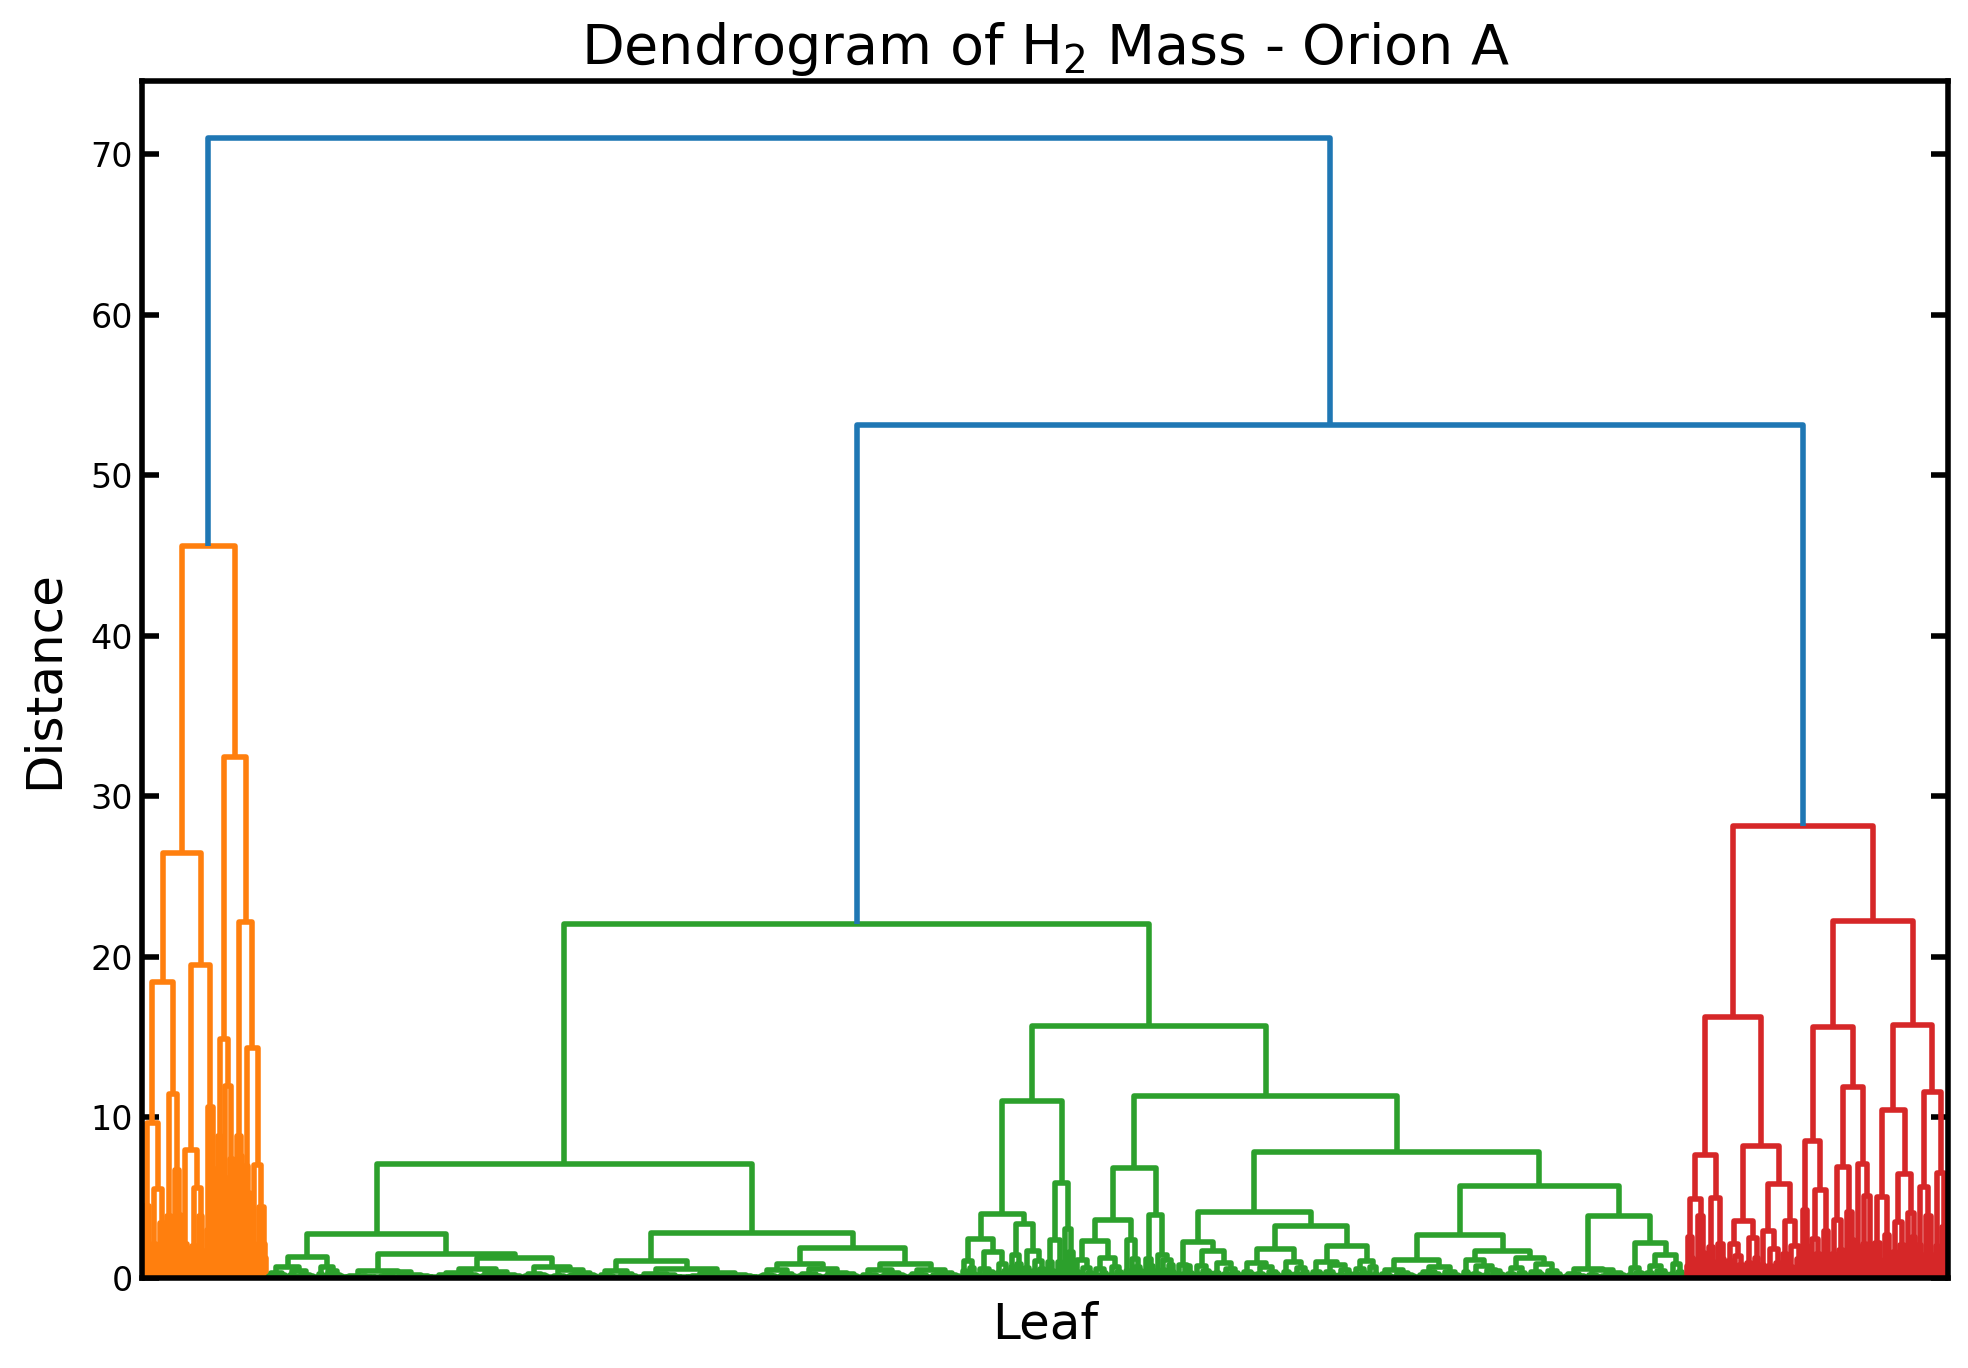

In [3]:
import scipy.cluster.hierarchy as sch
import matplotlib.pyplot as plt
import numpy as np

M_H2_OA = convert_to_mass(N_H2_OA)

# Perform hierarchical clustering
linkage_matrix = sch.linkage(M_H2_OA, method='ward')

# Create the dendrogram
plt.figure(figsize=(10, 7))
dendrogram = sch.dendrogram(linkage_matrix, no_labels=True, get_leaves=True)  # Remove default labels

# Customize the plot
plt.title("Dendrogram of H$_2$ Mass - Orion A", fontsize=20)
plt.xlabel("Leaf", fontsize=18)
plt.ylabel("Distance", fontsize=18)

# Set custom x-ticks: display fewer ticks by setting a stride
num_ticks = 0  # Number of ticks you want to show
xtick_positions = np.linspace(0, len(linkage_matrix), num_ticks, dtype=int)
plt.xticks(xtick_positions, labels=xtick_positions, fontsize=10)  # Set custom tick labels

plt.show()

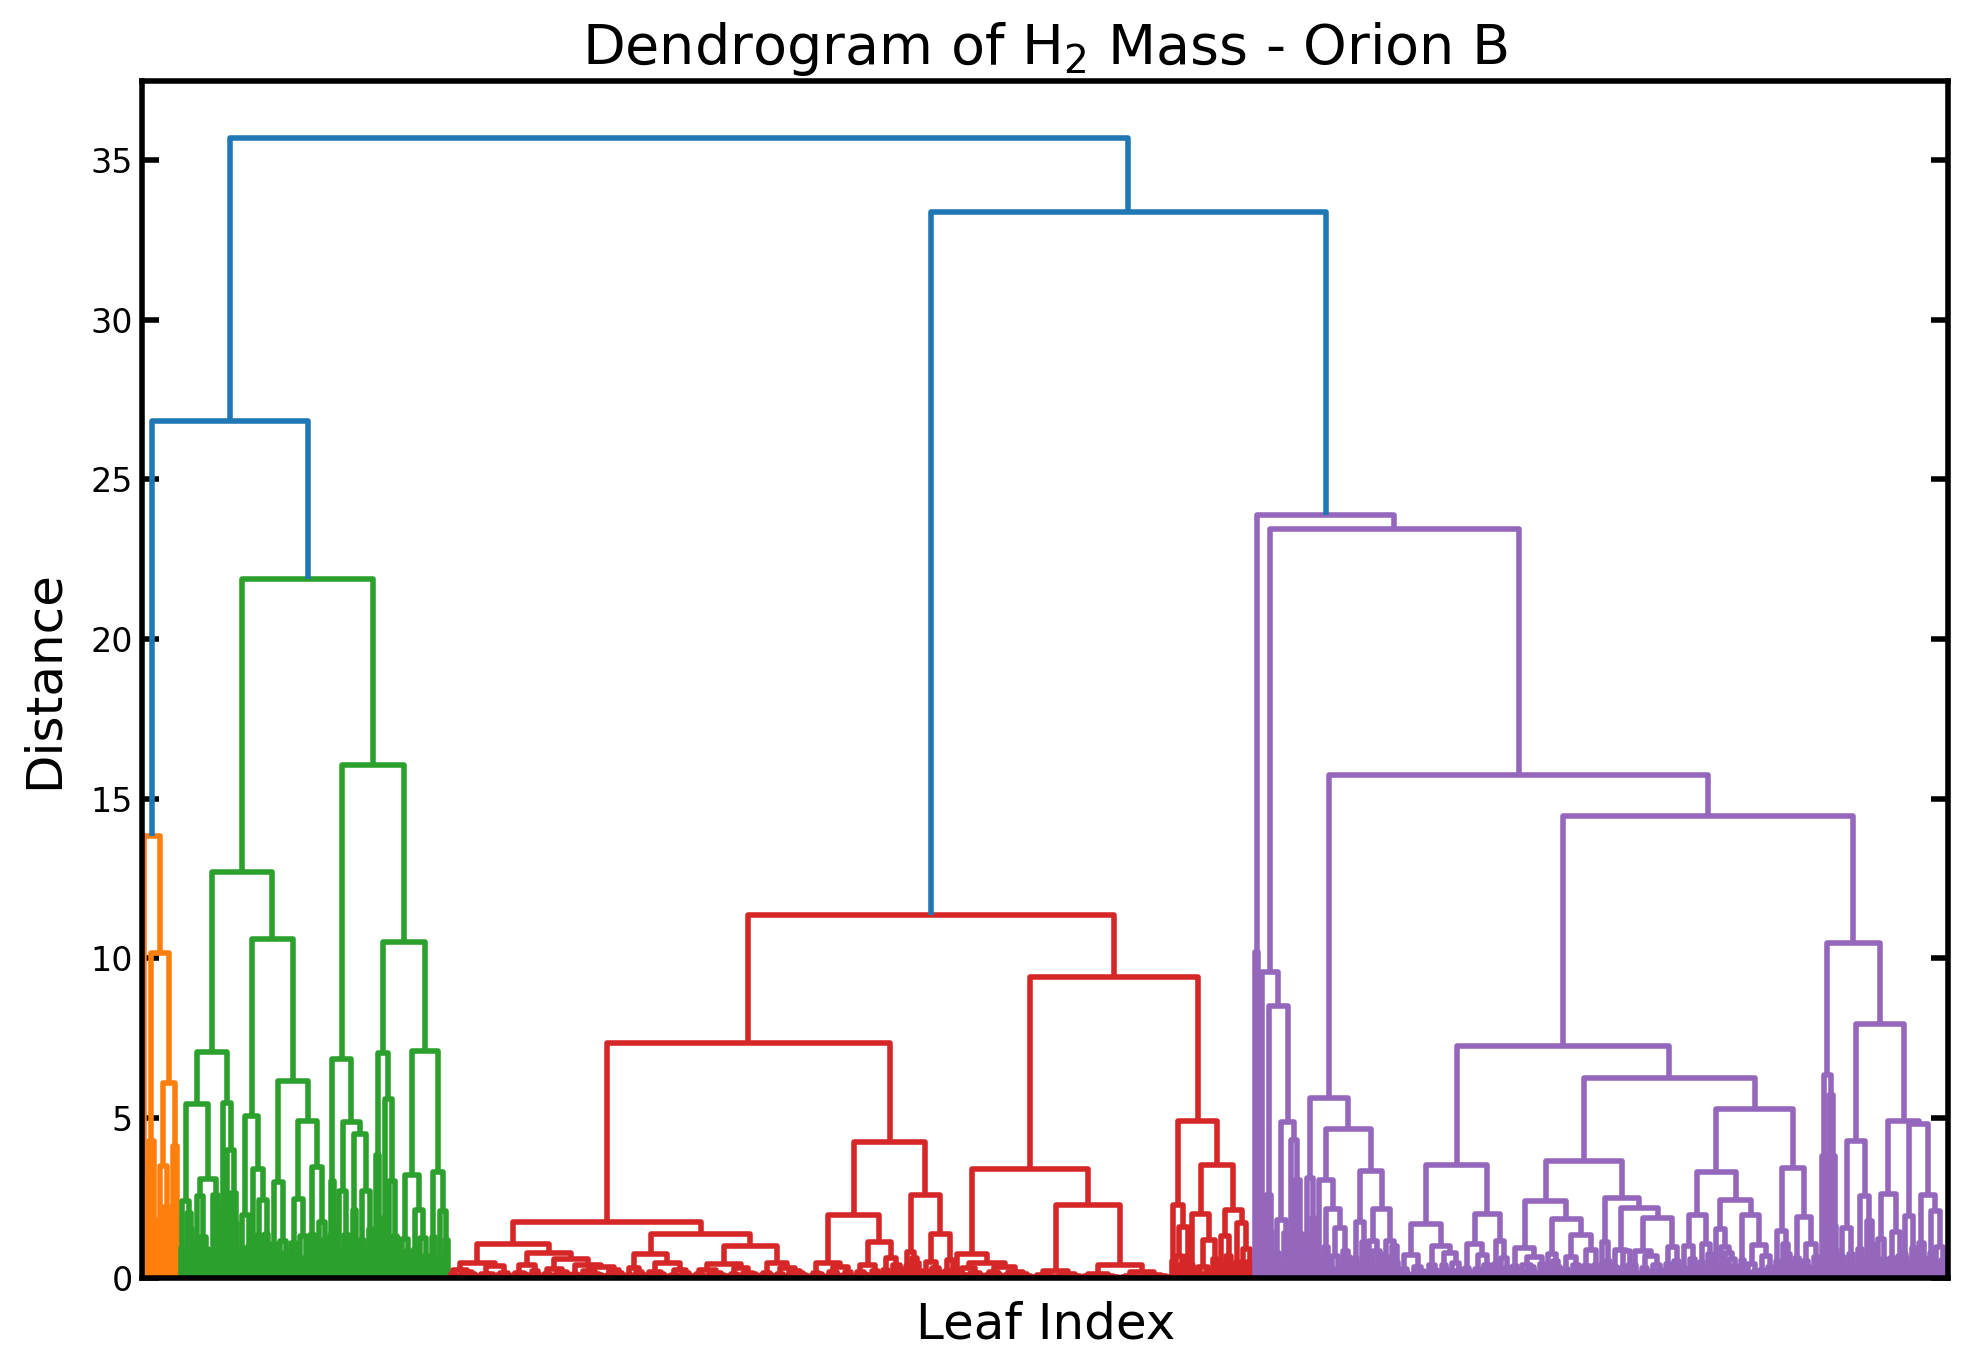

In [4]:
import scipy.cluster.hierarchy as sch
import matplotlib.pyplot as plt
import numpy as np

M_H2_OB = convert_to_mass(N_H2_OB)

# Perform hierarchical clustering
linkage_matrix = sch.linkage(M_H2_OB, method='ward')

# Create the dendrogram
plt.figure(figsize=(10, 7))
dendrogram = sch.dendrogram(linkage_matrix, no_labels=True)  # Remove default labels

# Customize the plot
plt.title("Dendrogram of H$_2$ Mass - Orion B", fontsize=20)
plt.xlabel("Leaf Index", fontsize=18)
plt.ylabel("Distance", fontsize=18)

# Set custom x-ticks: display fewer ticks by setting a stride
num_ticks = 0  # Number of ticks you want to show
xtick_positions = np.linspace(0, len(linkage_matrix), num_ticks, dtype=int)
plt.xticks(xtick_positions, labels=xtick_positions, fontsize=10)  # Set custom tick labels

plt.show()

In [5]:
from scipy import ndimage
from skimage.measure import perimeter

def pca_major_axis(region_coords):
    if len(region_coords) < 2:
        return 0
    centered_coords = region_coords - np.mean(region_coords, axis=0)
    cov_matrix = np.cov(centered_coords, rowvar=False)
    eigenvalues, _ = np.linalg.eigh(cov_matrix)
    major_axis = 2 * np.sqrt(np.max(eigenvalues))
    return major_axis

pixel_scale = 0.00417
distance = 412 
radians = 180/np.pi # conversion factor: rad in deg
rad_per_px = pixel_scale/radians
pc_per_px = np.sin(rad_per_px)*distance

min_value = np.percentile(M_H2_OA, 2)  # 2nd percentile
max_value = np.percentile(M_H2_OA, 100)  # 98th percentile

thresholds = np.linspace(min_value, max_value, 200)  # Example thresholds for mass map # M_sun/cm^2

region_masses_OA = []
region_sizes_OA = []
region_fractal_dims_OA = []
region_masks_OA = []

for threshold in thresholds:

    print(f"\nProcessing threshold: {threshold:.2f} M☉/cm²")
    
    # Step 1: Threshold the mass map
    structure_mask = M_H2_OA > threshold

    # Step 2: Label connected regions
    labeled_array, num_features = ndimage.label(structure_mask)

    if num_features == 0:
        print("No structures found at this threshold.")
        continue

    # Step 3: Compute areas of all structures
    region_areas = []
    for i in range(1, num_features + 1):
        area = np.sum(labeled_array == i)
        region_areas.append((i, area))

    # Sort by area descending
    region_areas.sort(key=lambda x: x[1], reverse=True)

    # Keep only top 10
    top_regions = region_areas[:50]
    
    # Step 4: Loop through selected regions
    for region_idx, area in top_regions:
        region_mask = labeled_array == region_idx
        region_masks_OA.append(region_mask)

        # Mass
        mass = np.sum(M_H2_OA[region_mask])
        region_masses_OA.append(mass)

        # Coordinates
        coords = np.argwhere(region_mask)

        # Size in pc
        size_px = pca_major_axis(coords)
        size_pc = size_px * pc_per_px
        region_sizes_OA.append(size_pc)

        # Find the coordinates of the region's pixels in flat index
        flat_indices = np.ravel_multi_index(coords.T, M_H2_OA.shape)

        # The dendrogram leaves correspond to flat indices of the original data
        # Find which leaves are present in this region
        region_leaves = set(flat_indices).intersection(set(dendrogram['leaves']))

        if region_leaves:
            # Find the first matching leaf index in the dendrogram
            leaf_idx = dendrogram['leaves'].index(next(iter(region_leaves)))
            print(f"Region {region_idx} corresponds to dendrogram leaf index: {leaf_idx}")
        else:
            print(f"Region {region_idx} does not correspond to any dendrogram leaf.")

        # Fractal Dimension
        region_binary = region_mask.astype(np.uint8)
        perim = perimeter(region_binary)
        if area > 5 and perim > 0:
            D = 2 * (np.log10(perim) / np.log10(area))
        else:
            D = np.nan  # handle degenerate cases
        region_fractal_dims_OA.append(D)

        print(f"Structure {region_idx}: Mass = {mass:.2f} M☉, Size ≈ {size_pc:.2f} pc, Fractal Dimension D ≈ {D:.2f}")


Processing threshold: 0.00 M☉/cm²
Region 1 corresponds to dendrogram leaf index: 557
Structure 1: Mass = 78869.68 M☉, Size ≈ 43.29 pc, Fractal Dimension D ≈ 1.23

Processing threshold: 0.05 M☉/cm²
Region 23 does not correspond to any dendrogram leaf.
Structure 23: Mass = 39940.47 M☉, Size ≈ 23.44 pc, Fractal Dimension D ≈ 1.49
Region 79 does not correspond to any dendrogram leaf.
Structure 79: Mass = 481.67 M☉, Size ≈ 2.64 pc, Fractal Dimension D ≈ 1.55
Region 919 does not correspond to any dendrogram leaf.
Structure 919: Mass = 124.65 M☉, Size ≈ 1.50 pc, Fractal Dimension D ≈ 1.66
Region 77 does not correspond to any dendrogram leaf.
Structure 77: Mass = 124.45 M☉, Size ≈ 0.98 pc, Fractal Dimension D ≈ 1.60
Region 816 does not correspond to any dendrogram leaf.
Structure 816: Mass = 108.76 M☉, Size ≈ 1.25 pc, Fractal Dimension D ≈ 1.57
Region 174 does not correspond to any dendrogram leaf.
Structure 174: Mass = 83.72 M☉, Size ≈ 1.33 pc, Fractal Dimension D ≈ 1.62
Region 10 does not c

<>:43: SyntaxWarning: invalid escape sequence '\o'
<>:43: SyntaxWarning: invalid escape sequence '\o'
C:\Users\User\AppData\Local\Temp\ipykernel_5596\3511317775.py:43: SyntaxWarning: invalid escape sequence '\o'
  plt.xlabel("Mass [M$_\odot$]", fontsize=18)


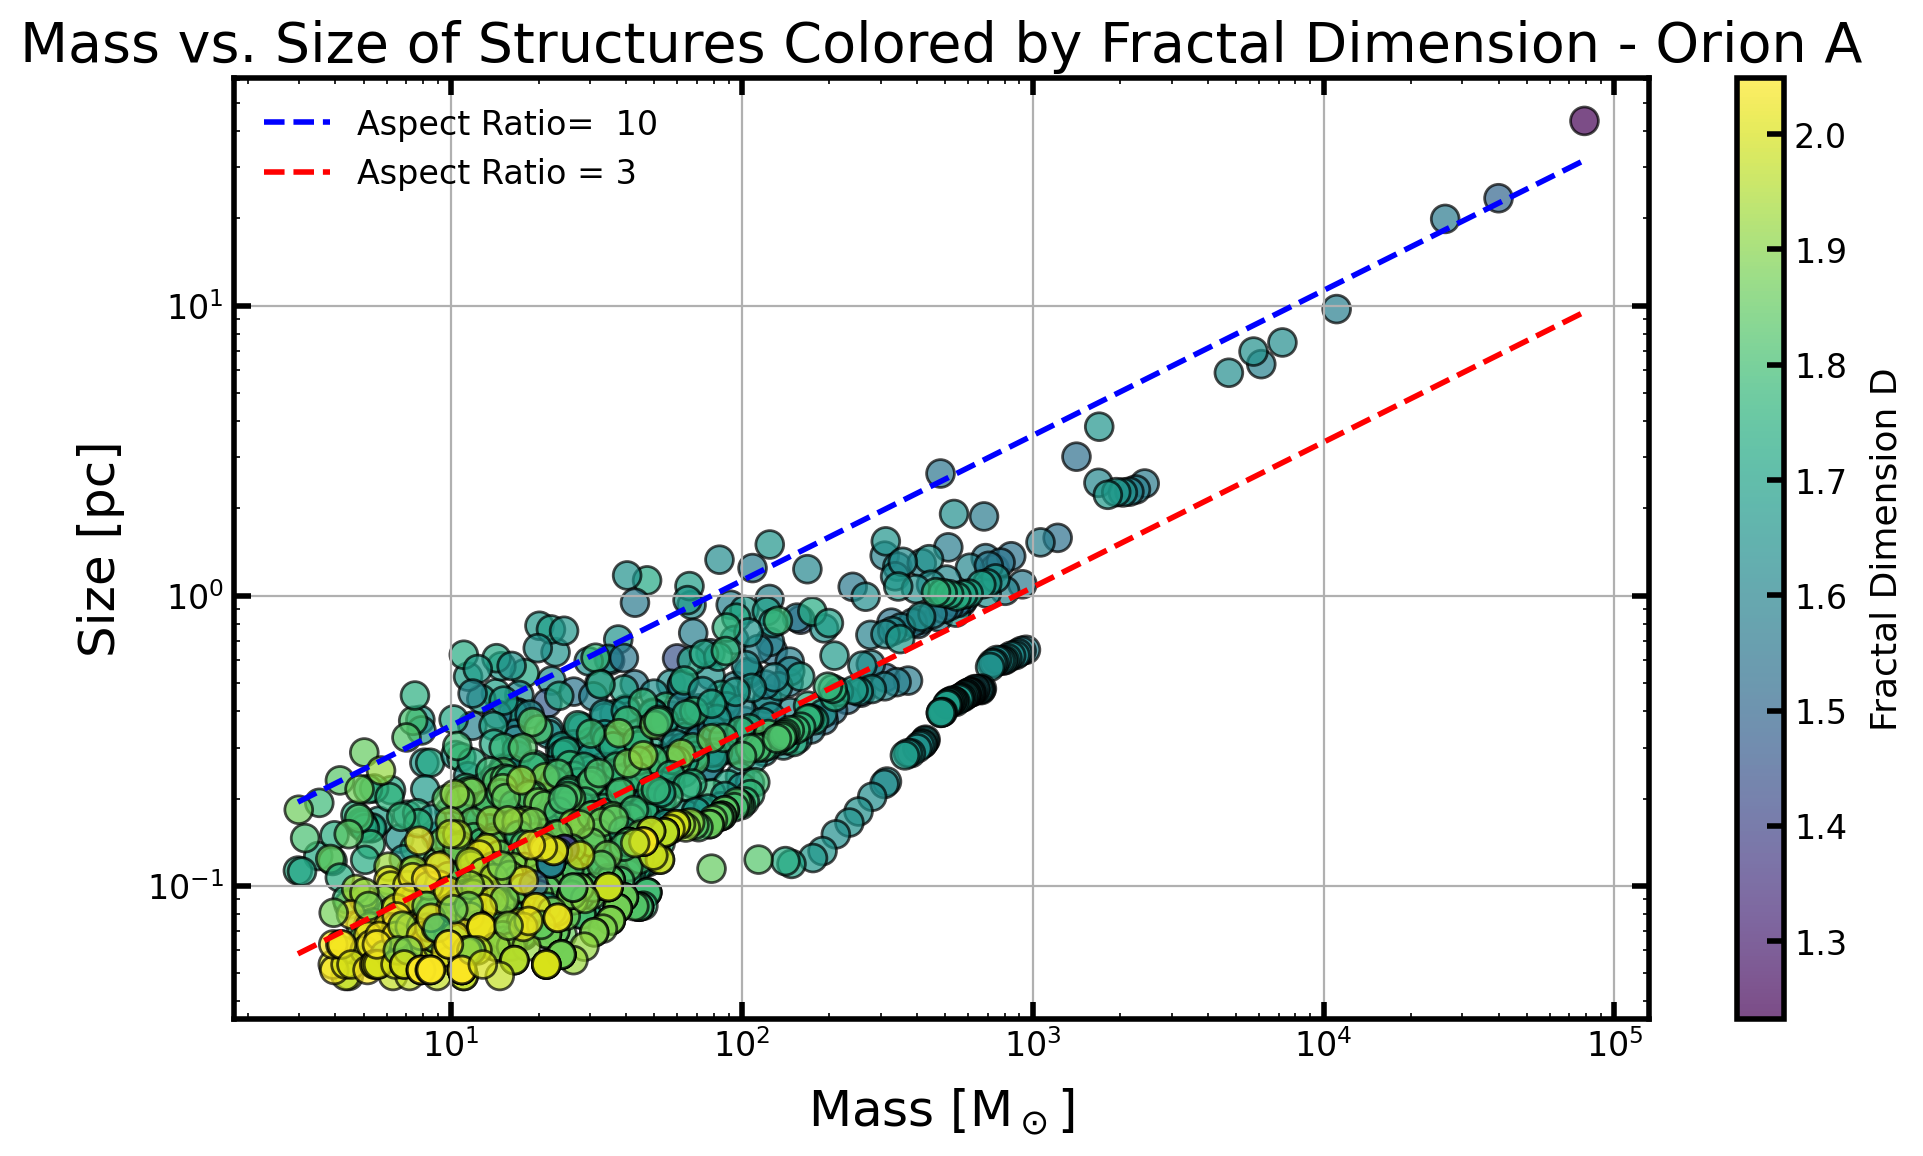

In [6]:
region_masses_OA = np.array(region_masses_OA)
region_sizes_OA = np.array(region_sizes_OA)
region_fractal_dims_OA = np.array(region_fractal_dims_OA)

mask = (region_fractal_dims_OA >= 1.2) & (region_fractal_dims_OA <= 2.05)
region_masses_OA = region_masses_OA[mask]
region_sizes_OA = region_sizes_OA[mask]
region_fractal_dims_OA = region_fractal_dims_OA[mask]

plt.figure(figsize=(10, 6))

sc = plt.scatter(region_masses_OA, region_sizes_OA, 
                 c=region_fractal_dims_OA, cmap='viridis', alpha=0.7, 
                 s=100, edgecolor='k')

cbar = plt.colorbar(sc)
cbar.set_label("Fractal Dimension D", fontsize=13)

M_min = np.min(region_masses_OA)
M_max = np.max(region_masses_OA)

M = np.logspace(np.log10(M_min), np.log10(M_max), 100)

b0 = 1e4  # cm^(-2)
G = 4.3e-3  # pc M_sun^-1 (km/s)^2
sigma = 2  # Assumed velocity dispersion in km/s (adjust if needed)

# Aspect Ratio 10
A_10 = 10
a_10 = (2 * A_10) / (np.pi * b0) ** 0.5
L_10 = a_10 * M ** 0.5

# Aspect Ratio 3
A_3 = 3
a_3 = (2 * A_3) / (np.pi * b0) ** 0.5
L_3 = a_3 * M ** 0.5

L_vir = (G * M) / (5 * sigma**2)

plt.plot(M, L_10, label="Aspect Ratio=  10", linestyle="--", color="blue")
plt.plot(M, L_3, label="Aspect Ratio = 3", linestyle="--", color="red")

plt.xlabel("Mass [M$_\odot$]", fontsize=18)
plt.ylabel("Size [pc]", fontsize=18)
plt.xscale("log")
plt.yscale("log")
plt.title("Mass vs. Size of Structures Colored by Fractal Dimension - Orion A", fontsize=18)
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.show()

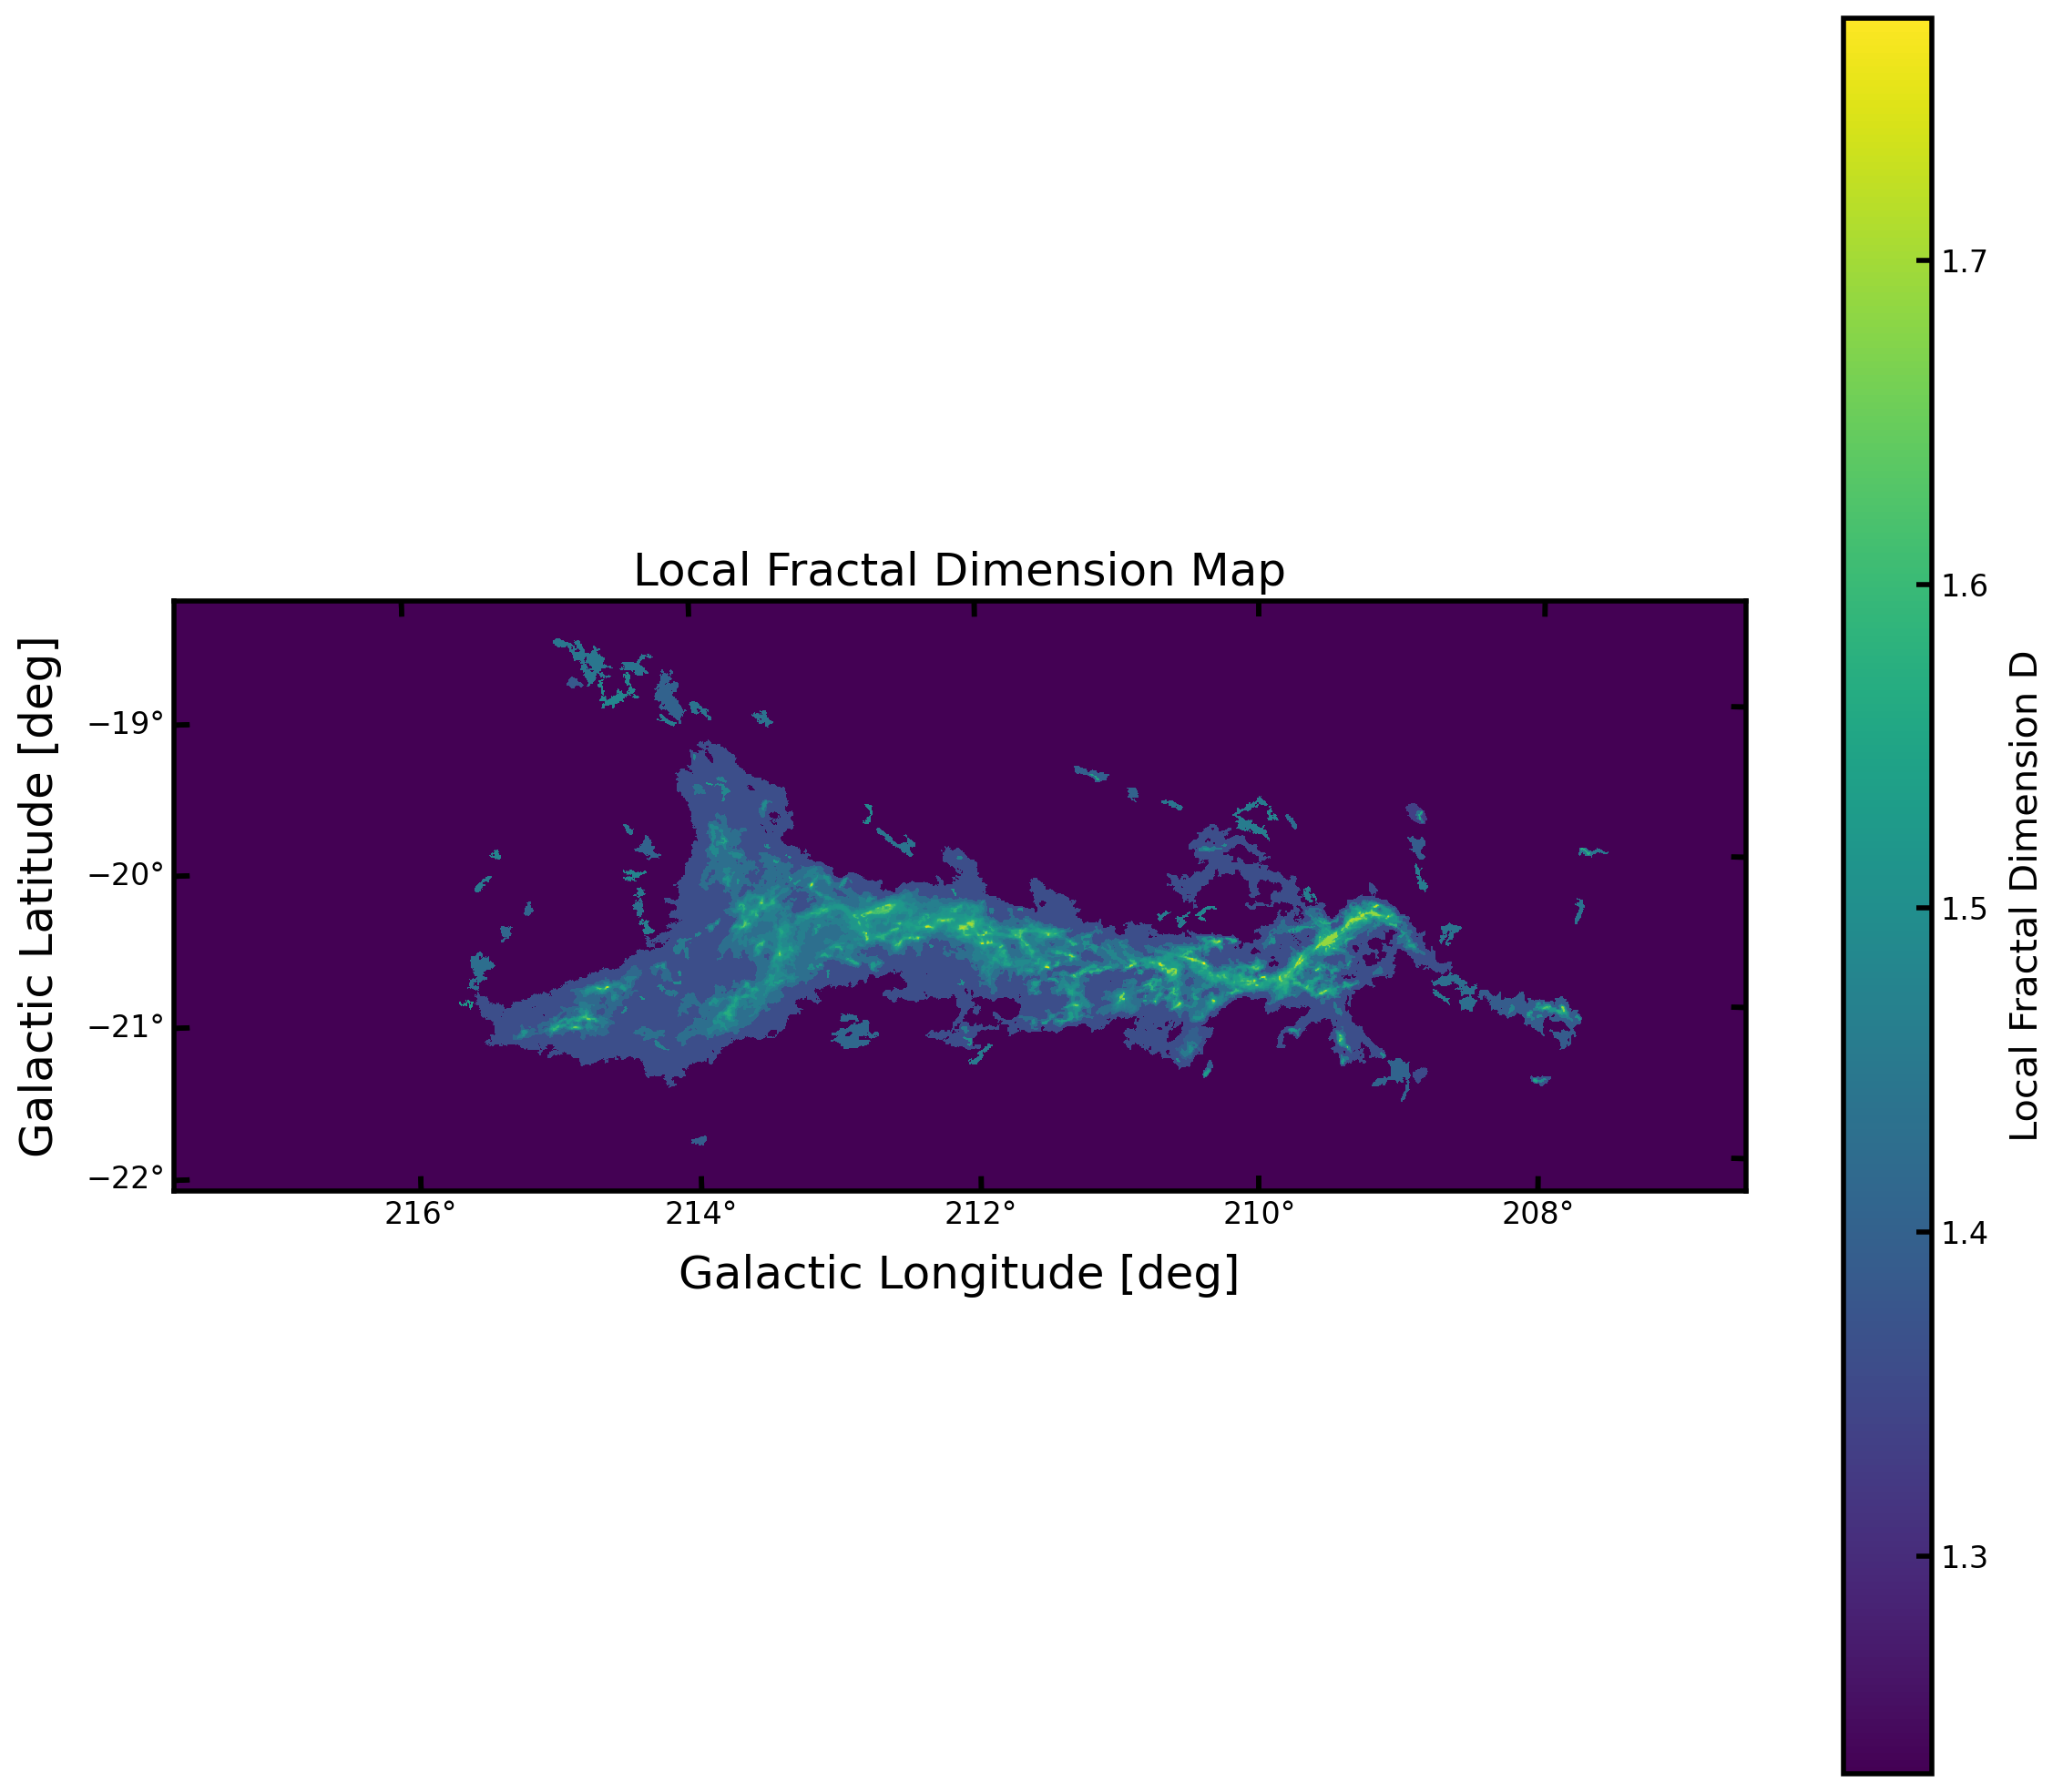

In [31]:
import numpy as np
import matplotlib.pyplot as plt

# == Initialize accumulation arrays ==
fractal_sum = np.zeros_like(N_H2_OA, dtype=float)
fractal_count = np.zeros_like(N_H2_OA, dtype=int)

# == Accumulate fractal values ==
for D, mask in zip(region_fractal_dims_OA, region_masks_OA):
    fractal_sum[mask] += D
    fractal_count[mask] += 1

# == Compute average fractal dimension per pixel ==
with np.errstate(divide='ignore', invalid='ignore'):
    fractal_avg = np.true_divide(fractal_sum, fractal_count)
    fractal_avg[fractal_count == 0] = np.nan  # Mask out pixels never hit

fractal_avg_filled = np.copy(fractal_avg)
fractal_avg_filled[np.isnan(fractal_avg_filled)] = np.nanmin(fractal_avg)

# == Plot ==
plt.figure(figsize=(12, 10))
ax = plt.subplot(111, projection=wcs[0])
im = ax.imshow(fractal_avg_filled, origin='lower', cmap='viridis')
ax.set_title("Local Fractal Dimension Map", fontsize=18)
ax.set_xlabel("Galactic Longitude [deg]", fontsize=18)
ax.set_ylabel("Galactic Latitude [deg]", fontsize=18)
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Local Fractal Dimension D", fontsize=15)
plt.show()

In [10]:
# correlation with YSOs map
import os
import pandas as pd
from astropy.coordinates import SkyCoord
import astropy.units as u


curr_folder = os.getcwd()

# ALL YSOs in the area
# Path to your .dat file
table_file_path = os.path.join(curr_folder, "Megeath", "table4.dat.txt")

# Define the column names (based on the provided table headers, modifying the RA and DE columns)
column_names = ['Seq', 'RA_DEC', 'Jmag', 'e_Jmag', 'Hmag', 'e_Hmag',
                'Kmag', 'e_Kmag', '[3.6]', 'e_[3.6]', '[4.5]', 'e_[4.5]', '[5.8]', 'e_[5.8]',
                '[8.0]', 'e_[8.0]', '[24]', 'e_[24]', 'AKs', 'alpha', 'Cl']

# Read the file, skipping the first few lines, assuming fixed-width formatting
data = pd.read_fwf(table_file_path, skiprows=5, names=column_names, delimiter="|")

# Now split the 'RA_DEC' column into individual RA and DEC components based on spaces
ra_dec_split = data['RA_DEC'].str.split(expand=True)

# Add the RA and DEC columns back to the DataFrame as integers/floats
data['RAh'] = 5
data['RAm'] = ra_dec_split[1].astype(float)
data['RAs'] = ra_dec_split[2].astype(float)
data['DEd'] = ra_dec_split[3].astype(float)
data['DEm'] = ra_dec_split[4].astype(float)
data['DEs'] = ra_dec_split[5].astype(float)

# Drop the original combined column
data.drop(columns=['RA_DEC'], inplace=True)

# Convert RA/DEC to decimal degrees
data['RA_deg'] = 15 * (data['RAh'] + data['RAm'] / 60 + data['RAs'] / 3600)
data['DEC_deg'] = data['DEd'] + np.sign(data['DEd'])*data['DEm'] / 60 + np.sign(data['DEd'])*data['DEs'] / 3600

# Handle negative declination degrees correctly
# data['DEC_deg'] = data.apply(lambda row: -row['DEC_deg'] if row['DEd'] < 0 else row['DEC_deg'], axis=1)

# Create SkyCoord object and transform to galactic coordinates
coords = SkyCoord(ra=data['RA_deg']*u.degree, dec=data['DEC_deg']*u.degree, frame='icrs', unit=u.degree)
data['l'] = coords.galactic.l.degree
data['b'] = coords.galactic.b.degree
# Orion A and Orion B
l_min_A, l_max_A = 206, 217
b_min_A, b_max_A = -21, -17

filtered_data_OA = data[(data['l'] >= 206) & (data['l'] <= 217) & (data['b'] >= -21) & (data['b'] <= -17)]

l_min_B, l_max_B = 203, 210
b_min_B, b_max_B = -17, -12

# Filter for objects within the specified galactic coordinates
filtered_data_OB = data[(data['l'] >= 203) & (data['l'] <= 210) & (data['b'] >= -17) & (data['b'] <= -12)]

C:\Users\User\AppData\Local\Temp\ipykernel_5596\1511237629.py:66: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper right')


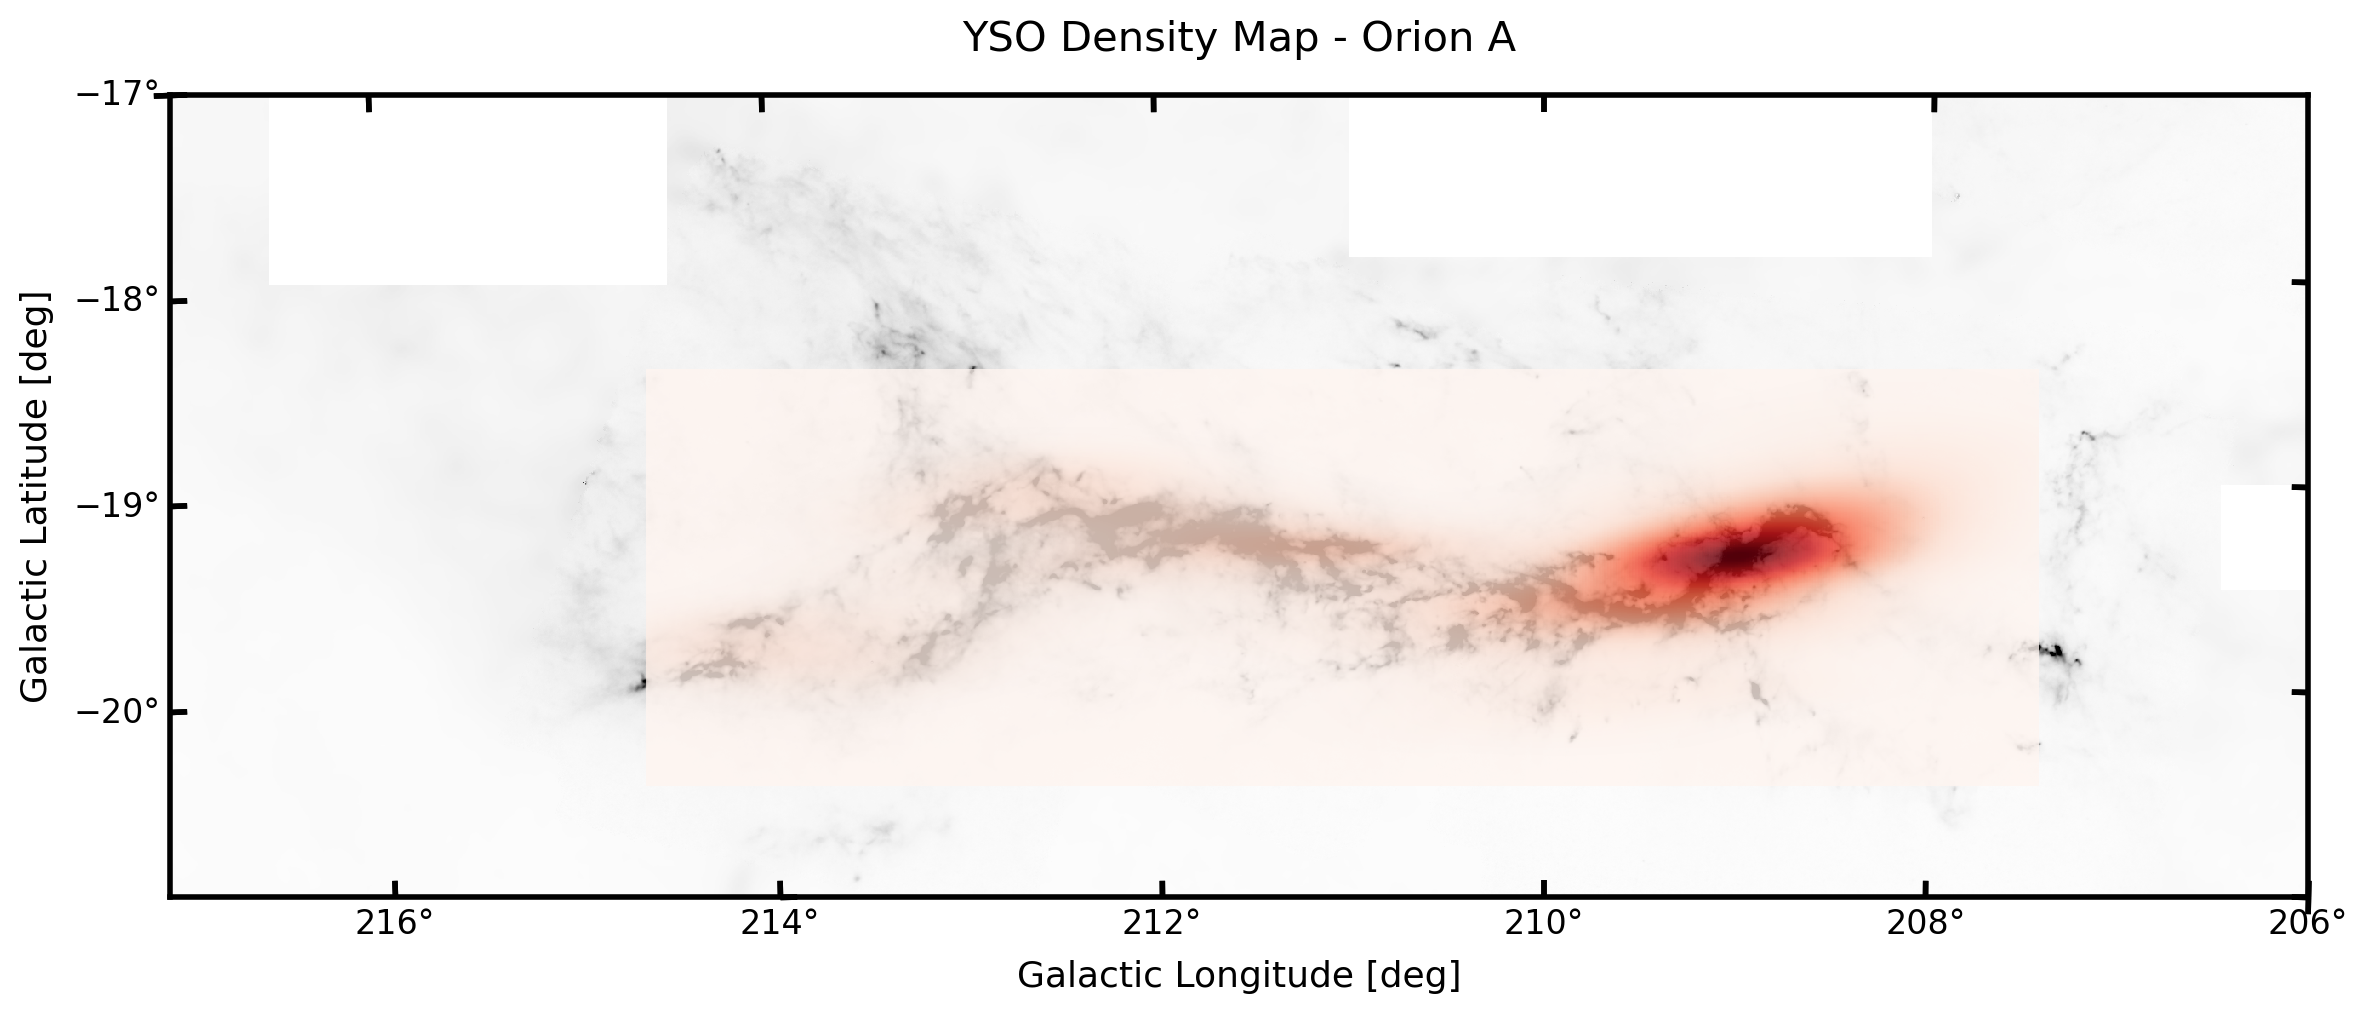

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.coordinates import SkyCoord
import astropy.units as u
from scipy.stats import gaussian_kde

# Convert Galactic coordinates to SkyCoord
yso_coords = SkyCoord(
    filtered_data_OA['l'].values, 
    filtered_data_OA['b'].values, 
    frame='galactic', 
    unit=u.deg
)

l_min_A, l_max_A = 206, 217
b_min_A, b_max_A = -21, -17

min_coord_A = SkyCoord(l_min_A, b_min_A, frame='galactic', unit=u.deg)
max_coord_A = SkyCoord(l_max_A, b_max_A, frame='galactic', unit=u.deg)

min_pixel_A = wcs[:][:][0].world_to_pixel(min_coord_A)
max_pixel_A = wcs[:][:][0].world_to_pixel(max_coord_A)

# Convert YSO world coords to pixel coords
yso_pixel_coords = np.array([wcs[0].world_to_pixel(coord) for coord in yso_coords])
x_pix = yso_pixel_coords[:, 0]
y_pix = yso_pixel_coords[:, 1]

# Compute 2D KDE for YSO density
xy = np.vstack([x_pix, y_pix])
kde = gaussian_kde(xy)
xgrid = np.linspace(min(x_pix), max(x_pix), N := 500)
ygrid = np.linspace(min(y_pix), max(y_pix), N)
X, Y = np.meshgrid(xgrid, ygrid)
positions = np.vstack([X.ravel(), Y.ravel()])
Z = kde(positions).reshape(X.shape)

# Plot background H₂ mass map
min_value = np.percentile(N_H2_OA, 1)
max_value = np.percentile(N_H2_OA, 99)

# Plot
plt.figure(figsize=(12, 10))
ax = plt.subplot(111, projection=wcs[0])

# Plot the map
sp = ax.imshow(N_H2, vmin=min_value, vmax=max_value, interpolation=None, origin='lower', cmap='Greys')
ax.set_title("Column Density Map of the Orion Complex", fontsize=15, pad=16)
ax.set_xlabel("Galactic Longitude [deg]", fontsize=13)
ax.set_ylabel("Galactic Latitude [deg]", fontsize=13)

# Overlay KDE density map of YSOs
ax.imshow(Z, extent=[xgrid.min(), xgrid.max(), ygrid.min(), ygrid.max()],
          origin='lower', cmap='Reds', alpha=0.8)

# Labels and limits
ax.set_title("YSO Density Map - Orion A", fontsize=15, pad=16)
ax.set_xlabel("Galactic Longitude [deg]", fontsize=13)
ax.set_ylabel("Galactic Latitude [deg]", fontsize=13)
ax.set(xlim=[max_pixel_A[0], min_pixel_A[0]], ylim=[min_pixel_A[1], max_pixel_A[1]])

# Optional: add original YSO points
# ax.plot(x_pix, y_pix, 'r*', markersize=2, label='YSOs')

# Add legend if needed
ax.legend(loc='upper right')
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_5596\3765110629.py:31: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper right')
c:\Users\User\anaconda3\envs\Astronomy_Env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.canvas.print_figure(bytes_io, **kw)


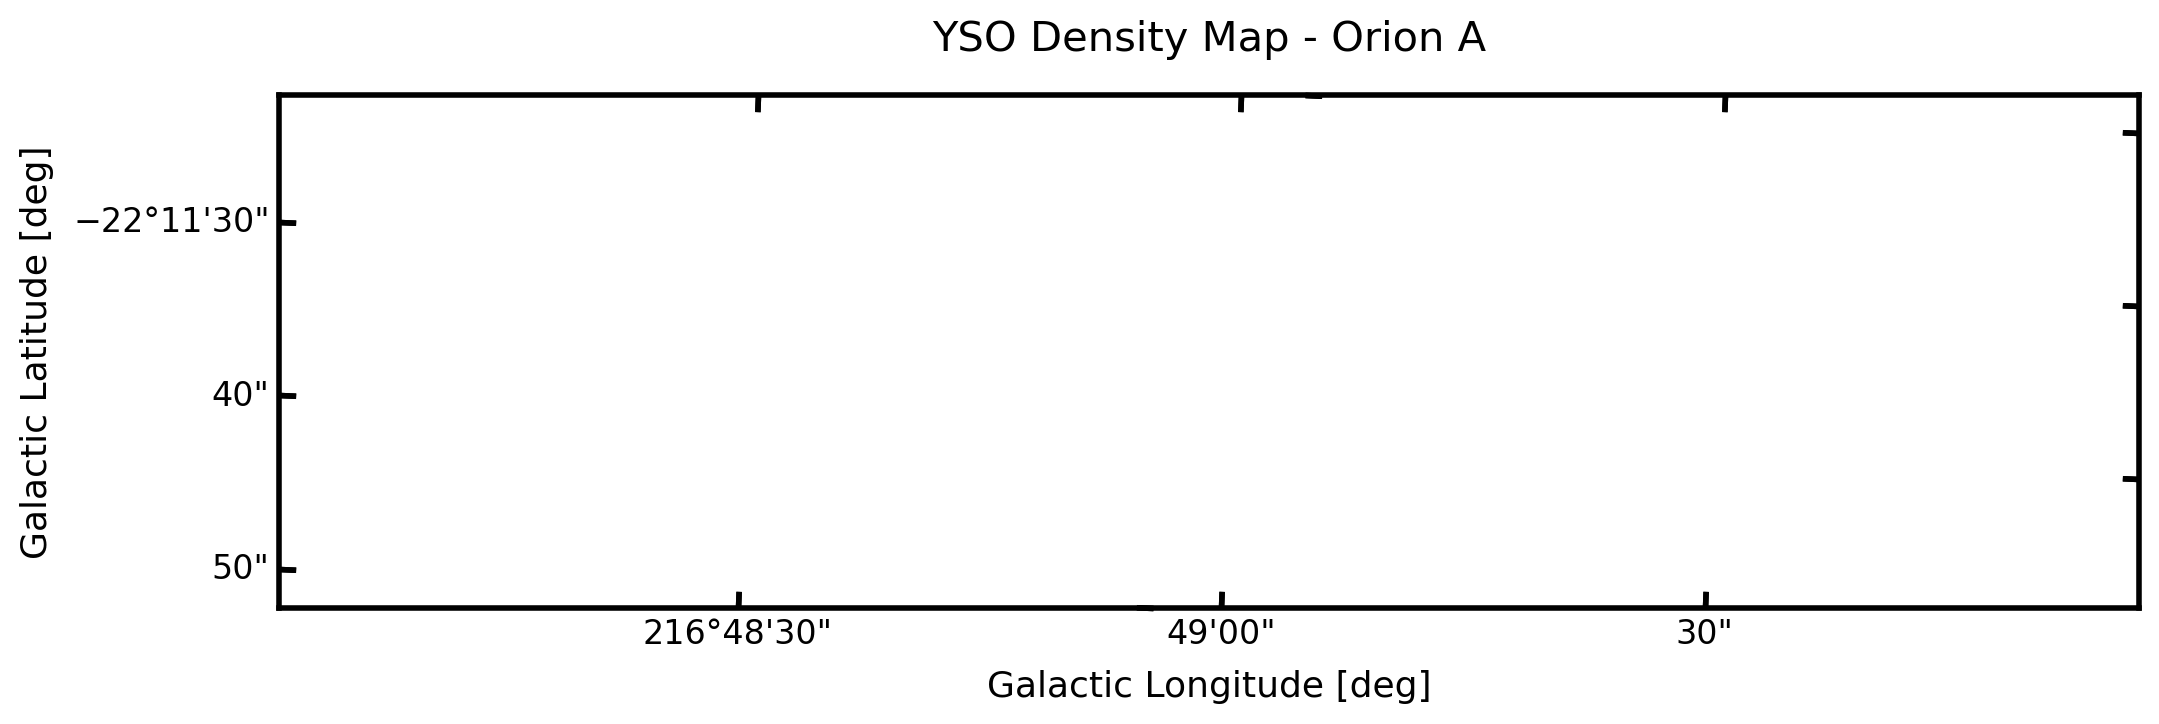

In [ ]:
plt.figure(figsize=(12, 10))
ax = plt.subplot(111, projection=wcs[0])

# Plot the map
sp = ax.imshow(fractal_avg, origin='lower', cmap='viridis')

# Overlay KDE density map of YSOs
ax.imshow(Z, extent=[xgrid.min(), xgrid.max(), ygrid.min(), ygrid.max()],
          origin='lower', cmap='Reds', alpha=0.8)

# # Labels and limits
ax.set_title("YSO Density Map - Orion A", fontsize=15, pad=16)
ax.set_xlabel("Galactic Longitude [deg]", fontsize=13)
ax.set_ylabel("Galactic Latitude [deg]", fontsize=13)
# ax.set(xlim=[max_pixel_A[0], min_pixel_A[0]], ylim=[min_pixel_A[1], max_pixel_A[1]])

# Optional: add original YSO points
# ax.plot(x_pix, y_pix, 'r*', markersize=2, label='YSOs')

# Add legend if needed
ax.legend(loc='upper right')
plt.show()

In [ ]:
from scipy import ndimage
from skimage.measure import perimeter
from collections import Counter

# Step 3: Define PCA major axis function
def pca_major_axis(region_coords):
    if len(region_coords) < 2:
        return 0
    centered_coords = region_coords - np.mean(region_coords, axis=0)
    cov_matrix = np.cov(centered_coords, rowvar=False)
    eigenvalues, _ = np.linalg.eigh(cov_matrix)
    major_axis = 2 * np.sqrt(np.max(eigenvalues))
    return major_axis

min_value = np.percentile(M_H2_OB, 2)  # 2nd percentile
max_value = np.percentile(M_H2_OB, 100)  # 98th percentile

thresholds = np.linspace(min_value, max_value, 200)  # Example thresholds for mass map # M_sun/cm^2

pixel_scale = 0.00417
distance = 412 
radians = 180/np.pi # conversion factor: rad in deg
rad_per_px = pixel_scale/radians
pc_per_px = np.sin(rad_per_px)*distance

region_masses_OB = []
region_sizes_OB = []
region_fractal_dims_OB = []

for threshold in thresholds:

    print(f"\nProcessing threshold: {threshold:.2f} M☉/cm²")
    
    # Step 1: Threshold the mass map
    structure_mask = M_H2_OB > threshold

    # Step 2: Label connected regions
    labeled_array, num_features = ndimage.label(structure_mask)

    if num_features == 0:
        print("No structures found at this threshold.")
        continue

    # Step 3: Compute areas of all structures
    region_areas = []
    for i in range(1, num_features + 1):
        area = np.sum(labeled_array == i)
        region_areas.append((i, area))

    # Sort by area descending
    region_areas.sort(key=lambda x: x[1], reverse=True)
            
    # Keep only top 10
    top_regions = region_areas[:50]

    # Step 4: Loop through selected regions
    for region_idx, area in top_regions:
        region_mask = labeled_array == region_idx

        # Mass
        mass = np.sum(M_H2_OB[region_mask])
        region_masses_OB.append(mass)

        # Coordinates
        coords = np.argwhere(region_mask)

        # Size in pc
        size_px = pca_major_axis(coords)
        size_pc = size_px * pc_per_px
        region_sizes_OB.append(size_pc)

        # Fractal Dimension
        region_binary = region_mask.astype(np.uint8)
        perim = perimeter(region_binary)
        if area > 5 and perim > 0:
            D = 2 * (np.log10(perim) / np.log10(area))
        else:
            D = np.nan  # handle degenerate cases
        region_fractal_dims_OB.append(D)

        print(f"Structure {region_idx}: Mass = {mass:.2f} M☉, Size ≈ {size_pc:.2f} pc, Fractal Dimension D ≈ {D:.2f}")



Processing threshold: 0.00 M☉/cm²
Structure 1: Mass = 54867.97 M☉, Size ≈ 24.60 pc, Fractal Dimension D ≈ 1.27

Processing threshold: 0.03 M☉/cm²
Structure 6: Mass = 32491.88 M☉, Size ≈ 19.12 pc, Fractal Dimension D ≈ 1.51
Structure 1526: Mass = 794.16 M☉, Size ≈ 4.58 pc, Fractal Dimension D ≈ 1.61
Structure 1869: Mass = 44.07 M☉, Size ≈ 0.82 pc, Fractal Dimension D ≈ 1.41
Structure 1858: Mass = 35.68 M☉, Size ≈ 0.57 pc, Fractal Dimension D ≈ 1.39
Structure 254: Mass = 73.78 M☉, Size ≈ 0.65 pc, Fractal Dimension D ≈ 1.44
Structure 1896: Mass = 24.78 M☉, Size ≈ 0.59 pc, Fractal Dimension D ≈ 1.43
Structure 1895: Mass = 24.13 M☉, Size ≈ 0.58 pc, Fractal Dimension D ≈ 1.43
Structure 1021: Mass = 21.63 M☉, Size ≈ 0.64 pc, Fractal Dimension D ≈ 1.76
Structure 277: Mass = 23.96 M☉, Size ≈ 1.04 pc, Fractal Dimension D ≈ 1.72
Structure 7: Mass = 16.23 M☉, Size ≈ 0.53 pc, Fractal Dimension D ≈ 1.61
Structure 171: Mass = 13.67 M☉, Size ≈ 0.78 pc, Fractal Dimension D ≈ 1.73
Structure 526: Mass =

<>:43: SyntaxWarning: invalid escape sequence '\o'
<>:43: SyntaxWarning: invalid escape sequence '\o'
C:\Users\User\AppData\Local\Temp\ipykernel_12304\1010912218.py:43: SyntaxWarning: invalid escape sequence '\o'
  plt.xlabel("Mass [M$_\odot$]", fontsize=14)


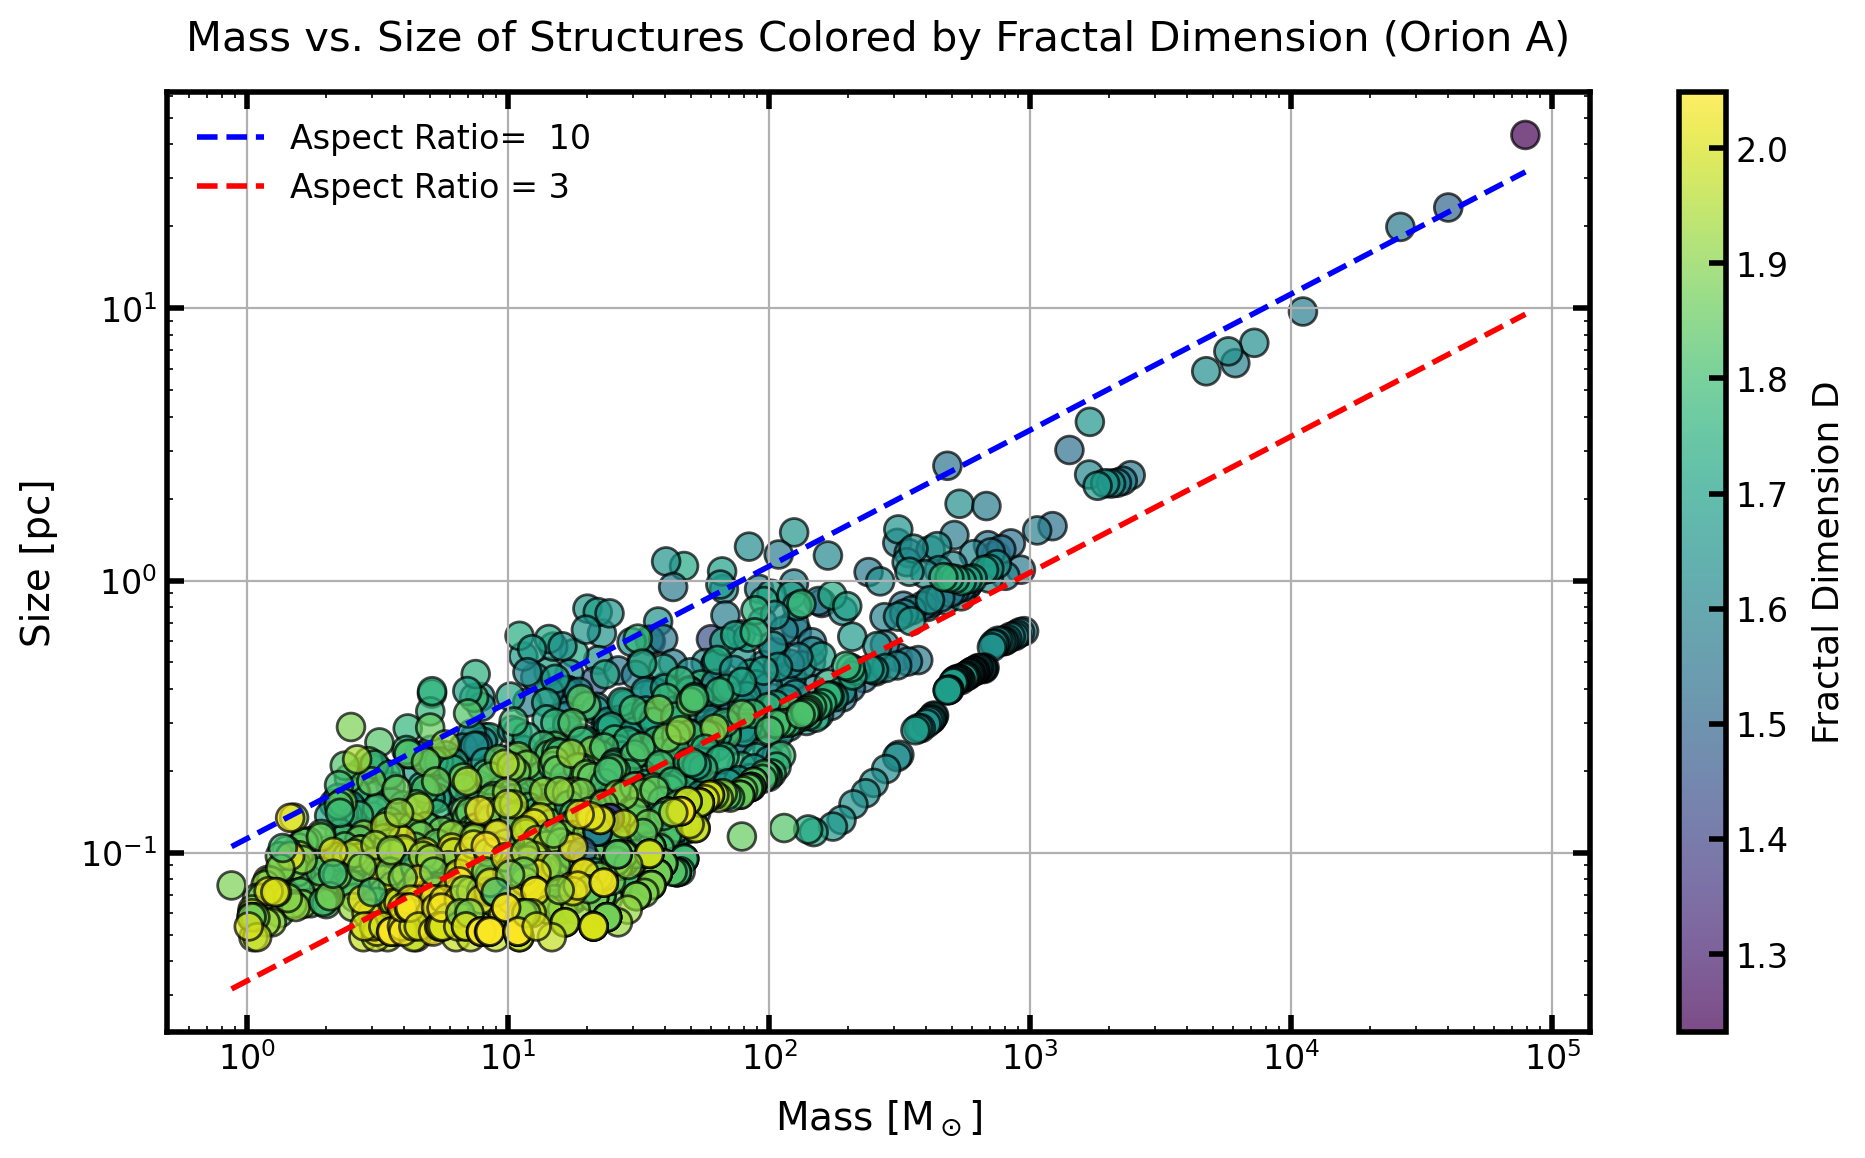

In [ ]:
region_masses_OA = np.array(region_masses_OA)
region_sizes_OA = np.array(region_sizes_OA)
region_fractal_dims_OA = np.array(region_fractal_dims_OA)

mask = (region_fractal_dims_OA >= 1.2) & (region_fractal_dims_OA <= 2.05)
region_masses_OA = region_masses_OA[mask]
region_sizes_OA = region_sizes_OA[mask]
region_fractal_dims_OA = region_fractal_dims_OA[mask]

plt.figure(figsize=(10, 6))

sc = plt.scatter(region_masses_OA, region_sizes_OA, 
                 c=region_fractal_dims_OA, cmap='viridis', alpha=0.7, 
                 s=100, edgecolor='k')

cbar = plt.colorbar(sc)
cbar.set_label("Fractal Dimension D", fontsize=13)

M_min = np.min(region_masses_OA)
M_max = np.max(region_masses_OA)

M = np.logspace(np.log10(M_min), np.log10(M_max), 100)

b0 = 1e4  # cm^(-2)
G = 4.3e-3  # pc M_sun^-1 (km/s)^2
sigma = 2  # Assumed velocity dispersion in km/s (adjust if needed)

# Aspect Ratio 10
A_10 = 10
a_10 = (2 * A_10) / (np.pi * b0) ** 0.5
L_10 = a_10 * M ** 0.5

# Aspect Ratio 3
A_3 = 3
a_3 = (2 * A_3) / (np.pi * b0) ** 0.5
L_3 = a_3 * M ** 0.5

L_vir = (G * M) / (5 * sigma**2)

plt.plot(M, L_10, label="Aspect Ratio=  10", linestyle="--", color="blue")
plt.plot(M, L_3, label="Aspect Ratio = 3", linestyle="--", color="red")

plt.xlabel("Mass [M$_\odot$]", fontsize=18)
plt.ylabel("Size [pc]", fontsize=18)
plt.xscale("log")
plt.yscale("log")
plt.title("Mass vs. Size of Structures Colored by Fractal Dimension - Orion A", fontsize=20)
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.show()

<>:43: SyntaxWarning: invalid escape sequence '\o'
<>:43: SyntaxWarning: invalid escape sequence '\o'
C:\Users\User\AppData\Local\Temp\ipykernel_12304\3003793289.py:43: SyntaxWarning: invalid escape sequence '\o'
  plt.xlabel("Mass [M$_\odot$]", fontsize=14)


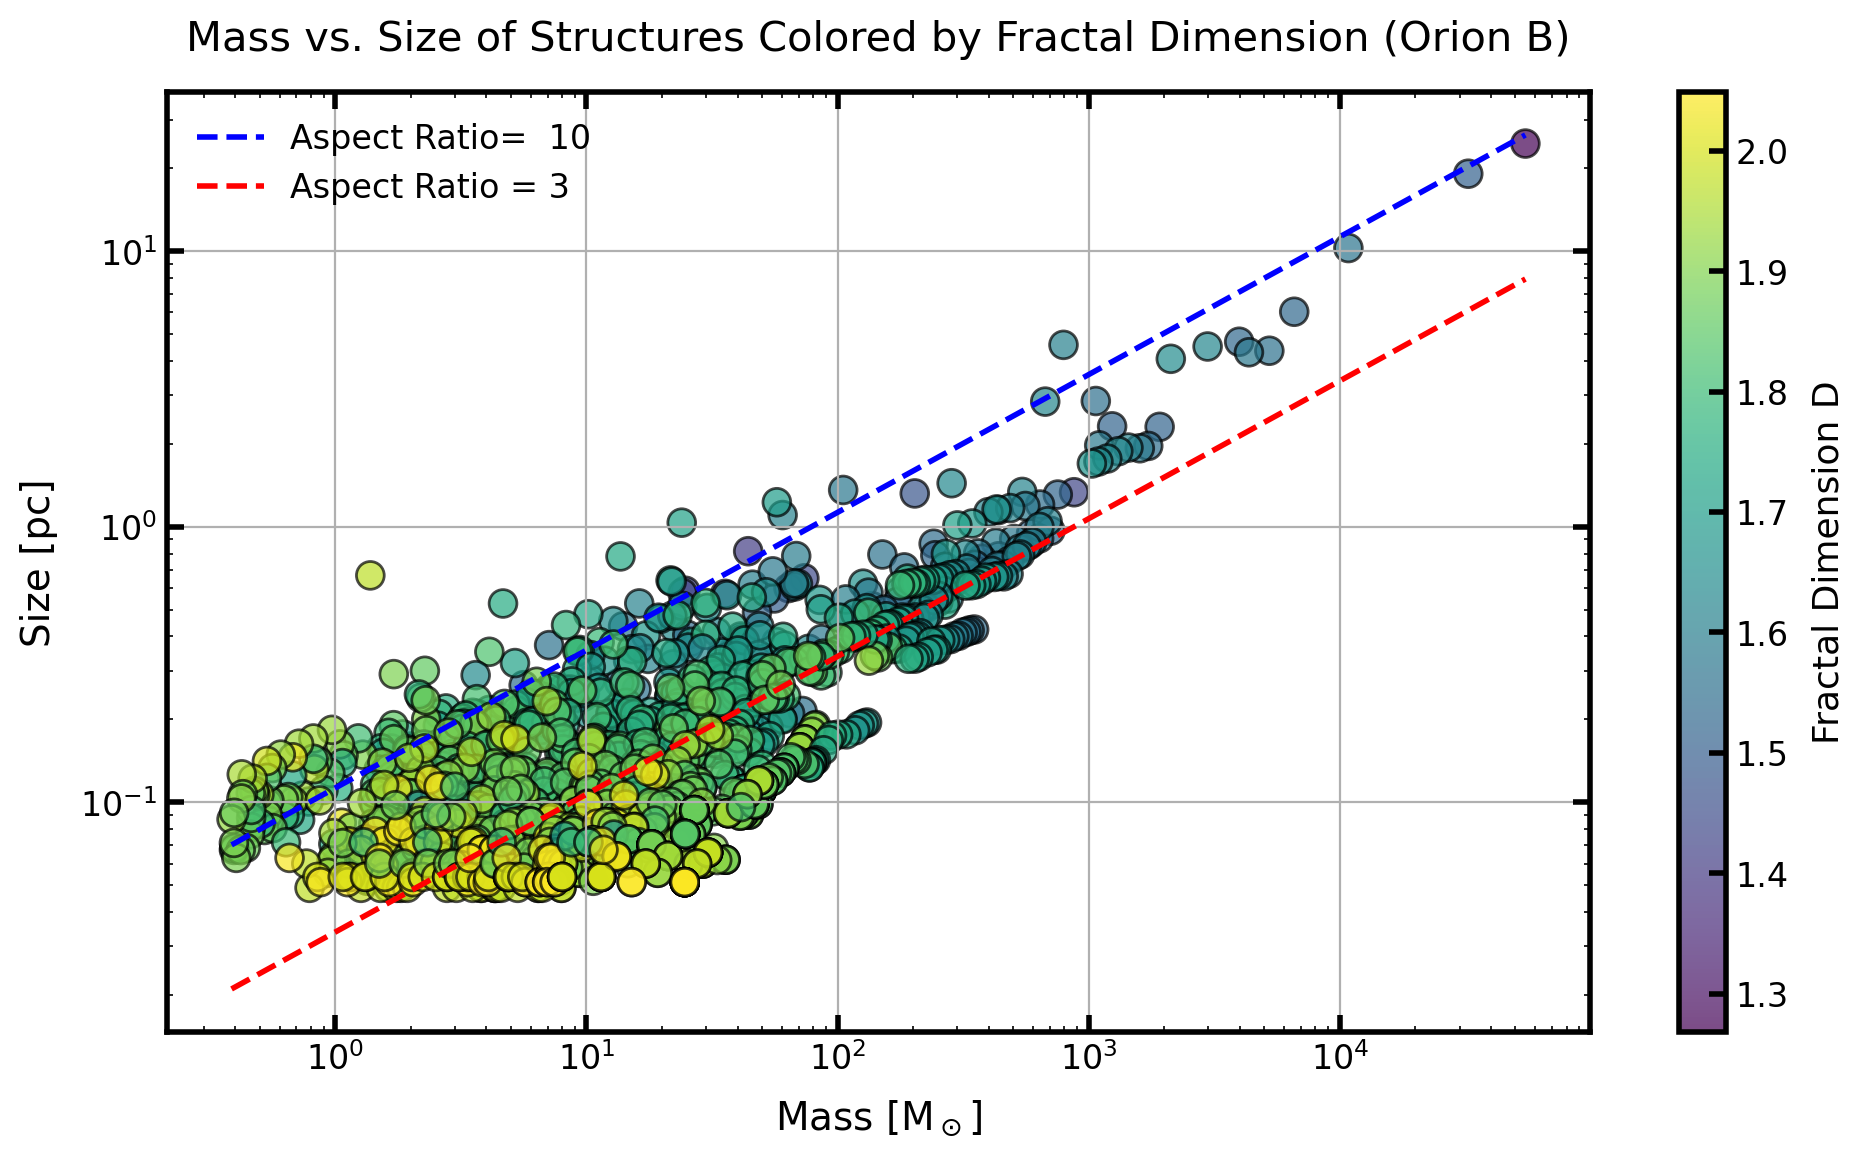

In [7]:
region_masses_OB = np.array(region_masses_OB)
region_sizes_OB = np.array(region_sizes_OB)
region_fractal_dims_OB = np.array(region_fractal_dims_OB)

mask = (region_fractal_dims_OB >= 1.2) & (region_fractal_dims_OB <= 2.05)
region_masses_OB = region_masses_OB[mask]
region_sizes_OB = region_sizes_OB[mask]
region_fractal_dims_OB = region_fractal_dims_OB[mask]

plt.figure(figsize=(10, 6))

sc = plt.scatter(region_masses_OB, region_sizes_OB, 
                 c=region_fractal_dims_OB, cmap='viridis', alpha=0.7, 
                 s=100, edgecolor='k')

cbar = plt.colorbar(sc)
cbar.set_label("Fractal Dimension D", fontsize=13)

M_min = np.min(region_masses_OB)
M_max = np.max(region_masses_OB)

M = np.logspace(np.log10(M_min), np.log10(M_max), 100)

b0 = 1e4  # cm^(-2)
G = 4.3e-3  # pc M_sun^-1 (km/s)^2
sigma = 2  # Assumed velocity dispersion in km/s (adjust if needed)

# Aspect Ratio 10
A_10 = 10
a_10 = (2 * A_10) / (np.pi * b0) ** 0.5
L_10 = a_10 * M ** 0.5

# Aspect Ratio 3
A_3 = 3
a_3 = (2 * A_3) / (np.pi * b0) ** 0.5
L_3 = a_3 * M ** 0.5

L_vir = (G * M) / (5 * sigma**2)

plt.plot(M, L_10, label="Aspect Ratio=  10", linestyle="--", color="blue")
plt.plot(M, L_3, label="Aspect Ratio = 3", linestyle="--", color="red")

plt.xlabel("Mass [M$_\odot$]", fontsize=14)
plt.ylabel("Size [pc]", fontsize=14)
plt.xscale("log")
plt.yscale("log")
plt.title("Mass vs. Size of Structures Colored by Fractal Dimension (Orion B)", fontsize=15, pad=15)
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.show()

<>:59: SyntaxWarning: invalid escape sequence '\o'
<>:59: SyntaxWarning: invalid escape sequence '\o'
C:\Users\User\AppData\Local\Temp\ipykernel_12304\1305513974.py:59: SyntaxWarning: invalid escape sequence '\o'
  plt.xlabel("Mass [M$_\odot$]", fontsize=14)


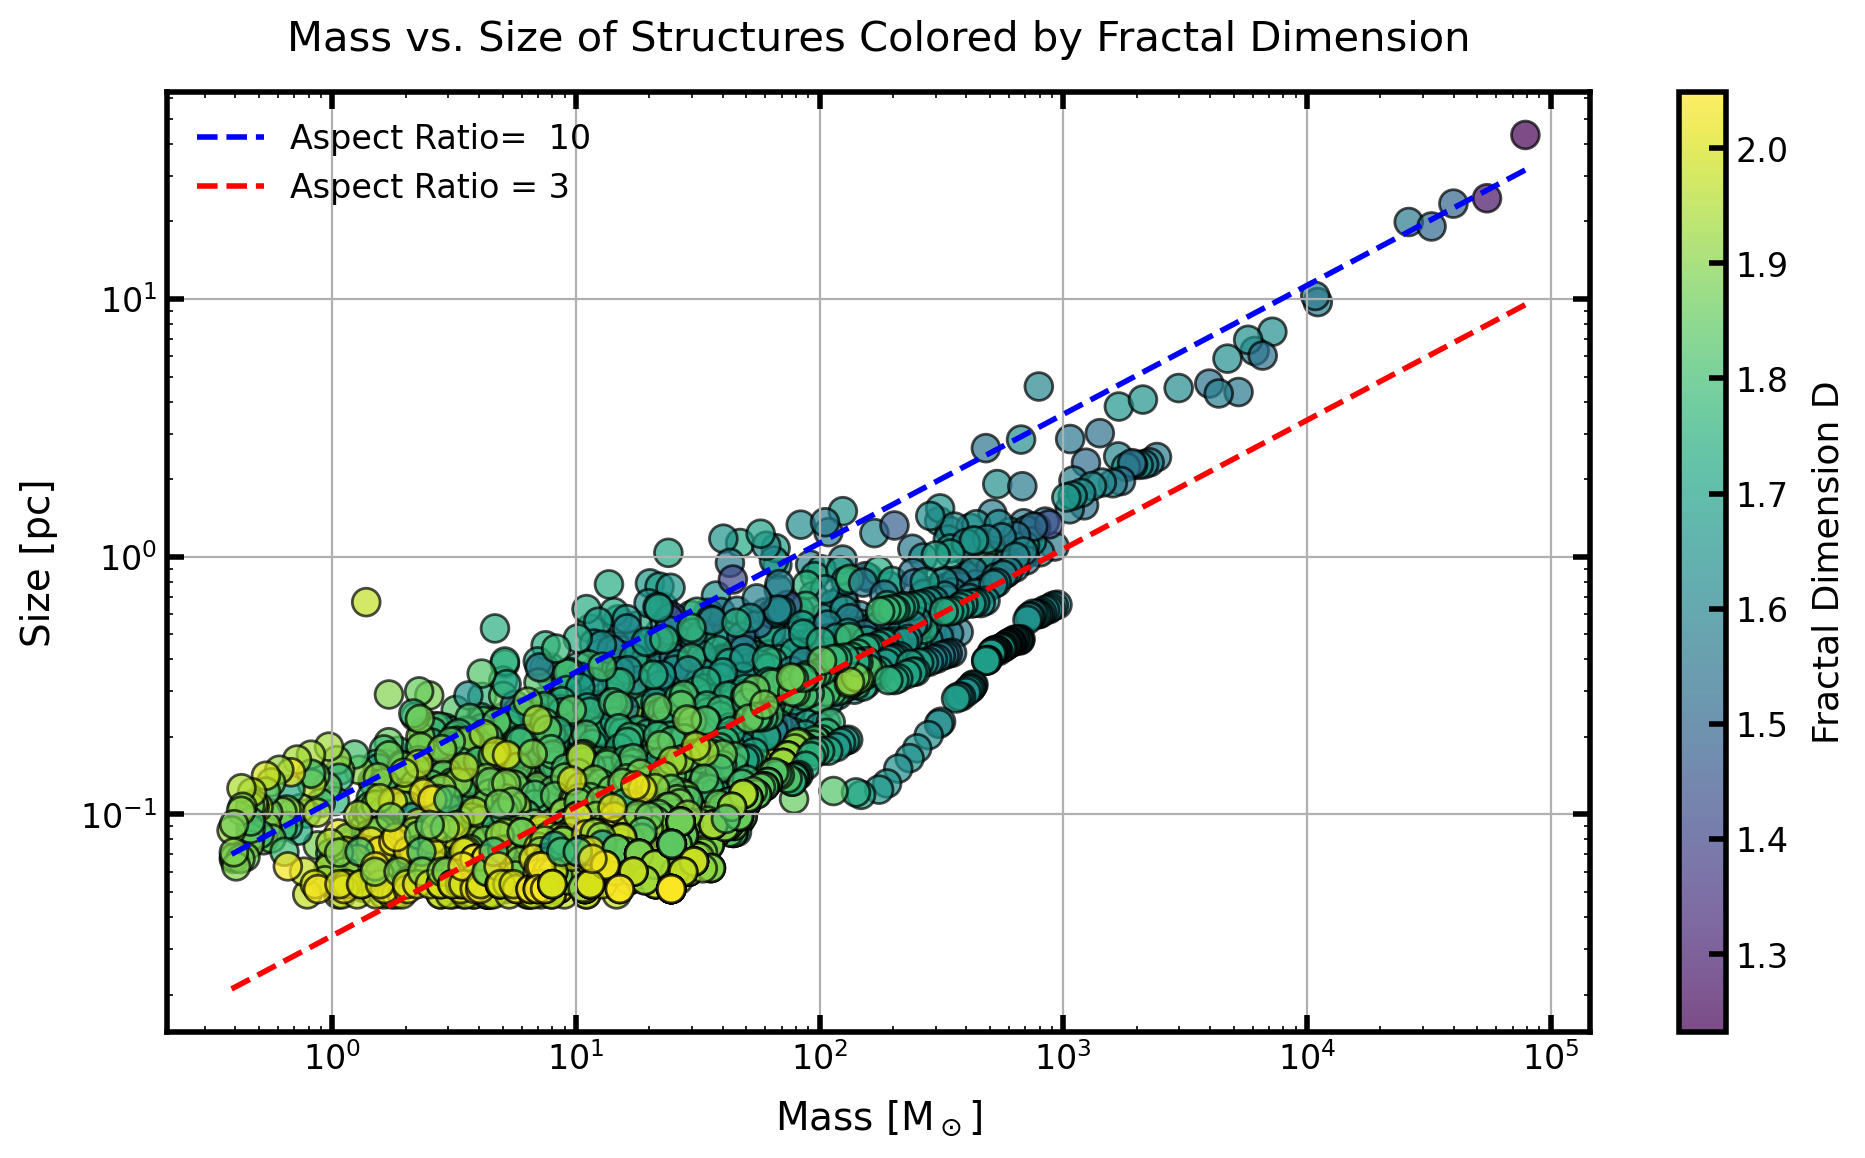

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Combine region masses, sizes, and fractal dimensions for OA and OB
region_masses_OA = region_masses_OA.tolist()
region_masses_OB = region_masses_OB.tolist()
region_sizes_OA = region_sizes_OA.tolist()
region_sizes_OB = region_sizes_OB.tolist()
region_fractal_dims_OA = region_fractal_dims_OA.tolist()
region_fractal_dims_OB = region_fractal_dims_OB.tolist()

region_masses = region_masses_OA + region_masses_OB
region_sizes = region_sizes_OA + region_sizes_OB
region_fractal_dims = region_fractal_dims_OA + region_fractal_dims_OB

# Remove all entries where mass or size is smaller than 1
region_masses = np.array(region_masses)
region_sizes = np.array(region_sizes)
region_fractal_dims = np.array(region_fractal_dims)

mask = (region_fractal_dims >= 1.2) & (region_fractal_dims <= 2.05)
region_masses = region_masses[mask]
region_sizes = region_sizes[mask]
region_fractal_dims = region_fractal_dims[mask]

plt.figure(figsize=(10, 6))

sc = plt.scatter(region_masses, region_sizes, 
                 c=region_fractal_dims, cmap='viridis', alpha=0.7, 
                 s=100, edgecolor='k')

cbar = plt.colorbar(sc)
cbar.set_label("Fractal Dimension D", fontsize=13)

M_min = np.min(region_masses)
M_max = np.max(region_masses)

M = np.logspace(np.log10(M_min), np.log10(M_max), 100)

b0 = 1e4  # cm^(-2)
G = 4.3e-3  # pc M_sun^-1 (km/s)^2
sigma = 2  # Assumed velocity dispersion in km/s (adjust if needed)

# Aspect Ratio 10
A_10 = 10
a_10 = (2 * A_10) / (np.pi * b0) ** 0.5
L_10 = a_10 * M ** 0.5

# Aspect Ratio 3
A_3 = 3
a_3 = (2 * A_3) / (np.pi * b0) ** 0.5
L_3 = a_3 * M ** 0.5

L_vir = (G * M) / (5 * sigma**2)

plt.plot(M, L_10, label="Aspect Ratio=  10", linestyle="--", color="blue")
plt.plot(M, L_3, label="Aspect Ratio = 3", linestyle="--", color="red")

plt.xlabel("Mass [M$_\odot$]", fontsize=14)
plt.ylabel("Size [pc]", fontsize=14)
plt.xscale("log")
plt.yscale("log")
plt.title("Mass vs. Size of Structures Colored by Fractal Dimension", fontsize=15, pad=15)
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.show()

In [ ]:
# maybe the exagon thing

In [9]:
from scipy.interpolate import interp1d

# Calculate which points are below the A_3 line (L_3)
# region_masses, region_sizes, region_fractal_dims are already filtered and combined arrays

# Interpolate L_3 for the given region_masses (log-log space for consistency)

# Only consider points within the mass range of L_3
mass_mask = (region_masses >= np.min(M)) & (region_masses <= np.max(M))
filtered_masses = region_masses[mass_mask]
filtered_sizes = region_sizes[mass_mask]
filtered_fractal_dims = region_fractal_dims[mass_mask]

# Interpolate L_3 at the filtered masses
L3_interp = interp1d(M, L_3, bounds_error=False, fill_value="extrapolate")
L3_at_mass = L3_interp(filtered_masses)

# Find points below the A_3 line
below_A3_mask = filtered_sizes < L3_at_mass

# Stats for points below A_3 line
num_points = np.sum(below_A3_mask)
mean_mass = np.mean(filtered_masses[below_A3_mask]) if num_points > 0 else np.nan
mean_size = np.mean(filtered_sizes[below_A3_mask]) if num_points > 0 else np.nan
mean_D = np.mean(filtered_fractal_dims[below_A3_mask]) if num_points > 0 else np.nan

print(f"Number of points below A_3 line: {num_points}")
print(f"Mean mass: {mean_mass:.3f}")
print(f"Mean size: {mean_size:.3f}")
print(f"Mean fractal dimension: {mean_D:.3f}")

Number of points below A_3 line: 1463
Mean mass: 58.146
Mean size: 0.132
Mean fractal dimension: 1.847


In [10]:
# Calculate which points are above the A_3 line (L_3)
# region_masses, region_sizes, region_fractal_dims, M, L_3, and L3_interp are already defined

# Only consider points within the mass range of L_3
mass_mask = (region_masses >= np.min(M)) & (region_masses <= np.max(M))
filtered_masses = region_masses[mass_mask]
filtered_sizes = region_sizes[mass_mask]
filtered_fractal_dims = region_fractal_dims[mass_mask]

# Interpolate L_3 at the filtered masses
L3_at_mass = L3_interp(filtered_masses)

# Find points above the A_3 line
above_A3_mask = filtered_sizes >= L3_at_mass

# Stats for points above A_3 line
num_points_above = np.sum(above_A3_mask)
mean_mass_above = np.mean(filtered_masses[above_A3_mask]) if num_points_above > 0 else np.nan
mean_size_above = np.mean(filtered_sizes[above_A3_mask]) if num_points_above > 0 else np.nan
mean_D_above = np.mean(filtered_fractal_dims[above_A3_mask]) if num_points_above > 0 else np.nan

print(f"Number of points above A_3 line: {num_points_above}")
print(f"Mean mass: {mean_mass_above:.3f}")
print(f"Mean size: {mean_size_above:.3f}")
print(f"Mean fractal dimension: {mean_D_above:.3f}")

Number of points above A_3 line: 1754
Mean mass: 196.408
Mean size: 0.382
Mean fractal dimension: 1.772


In [2]:
import pickle
import numpy as np

with open("structure_data_OA.pkl", "rb") as f:
    structure_data_OA = pickle.load(f)

with open("structure_data_OB.pkl", "rb") as f:
    structure_data_OB = pickle.load(f)

# Convert your collected data to arrays
region_masses_OA = np.array([s["mass"] for s in structure_data_OA])
region_sizes_OA = np.array([s["size_pc"] for s in structure_data_OA])
region_fractal_dims_OA = np.array([s["fractal_dimension"] for s in structure_data_OA])

mask = region_fractal_dims_OA <= 2.05
region_masses_OA = region_masses_OA[mask]
region_sizes_OA = region_sizes_OA[mask]
region_fractal_dims_OA = region_fractal_dims_OA[mask]

# Remove NaNs for plotting
valid = ~np.isnan(region_masses_OA) & ~np.isnan(region_sizes_OA) & ~np.isnan(region_fractal_dims_OA)
region_masses_OA = region_masses_OA[valid]
region_sizes_OA = region_sizes_OA[valid]
region_fractal_dims_OA = region_fractal_dims_OA[valid]

# OB
region_masses_OB = np.array([s["mass"] for s in structure_data_OB])
region_sizes_OB = np.array([s["size_pc"] for s in structure_data_OB])
region_fractal_dims_OB = np.array([s["fractal_dimension"] for s in structure_data_OB])

mask = region_fractal_dims_OB <= 2.05
region_masses_OB = region_masses_OB[mask]
region_sizes_OB = region_sizes_OB[mask]
region_fractal_dims_OB = region_fractal_dims_OB[mask]

# Remove NaNs for plotting
valid = ~np.isnan(region_masses_OB) & ~np.isnan(region_sizes_OB) & ~np.isnan(region_fractal_dims_OB)
region_masses_OB = region_masses_OB[valid]
region_sizes_OB = region_sizes_OB[valid]
region_fractal_dims_OB = region_fractal_dims_OB[valid]

In [3]:
import pyvista as pv
import numpy as np

# Prepare data (use OA as example, or combine OA+OB if desired)
region_masses = np.concatenate([region_masses_OA, region_masses_OB])
region_sizes = np.concatenate([region_sizes_OA, region_sizes_OB])
region_fractal_dims = np.concatenate([region_fractal_dims_OA, region_fractal_dims_OB])

# Remove NaNs and filter for valid fractal dimension range
mask = (~np.isnan(region_fractal_dims)) & (region_fractal_dims >= 1.2) & (region_fractal_dims <= 2.1)
region_masses = region_masses[mask]
region_sizes = region_sizes[mask]
region_fractal_dims = region_fractal_dims[mask]

# Log scale for mass and size for better visualization
points = np.column_stack((np.log10(region_masses), np.log10(region_sizes), region_fractal_dims))

cloud = pv.PolyData(points)
plotter = pv.Plotter()
plotter.add_points(cloud, render_points_as_spheres=True, point_size=6, scalars=region_fractal_dims, cmap="viridis")
plotter.set_background("white")

labels = dict(zlabel='D', xlabel='log10(Mass)', ylabel='log10(Size)')

plotter.add_axes(**labels)
plotter.show_grid(**labels)
plotter.add_title("Mass-Size-D Plane")
plotter.show()

c:\Users\User\anaconda3\envs\Astronomy_Env\Lib\site-packages\pyvista\plotting\renderer.py:1846: PyVistaDeprecationWarning: `xlabel` is deprecated. Use `xtitle` instead.
  warnings.warn(
c:\Users\User\anaconda3\envs\Astronomy_Env\Lib\site-packages\pyvista\plotting\renderer.py:1852: PyVistaDeprecationWarning: `ylabel` is deprecated. Use `ytitle` instead.
  warnings.warn(
c:\Users\User\anaconda3\envs\Astronomy_Env\Lib\site-packages\pyvista\plotting\renderer.py:1858: PyVistaDeprecationWarning: `zlabel` is deprecated. Use `ztitle` instead.
  warnings.warn(


Widget(value='<iframe src="http://localhost:53110/index.html?ui=P_0x23991084a10_0&reconnect=auto" class="pyvis…